# Wheat Yield Forecast 2026–2030 — Multan Division
### All 7 Models | 2 Scenarios | 4 Districts
**Models:** XGBoost, LSTM, TCN, SERWI XGB+LSTM, SERWI TCN+XGB, SERWI LSTM+TCN, SERWI Triple  
**Scenarios:** A (Primary: NDVI-Climate, LST-Trend) | B (Reference: NDVI-Trend, LST-Climate)  
**Save path:** `/content/drive/MyDrive/Colab Notebooks/Wheat_Future_Forecast/`

## CELL 1 — Mount Drive + Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install keras-tcn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_squared_error
print('TF:', tf.__version__)
print('Ready')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF: 2.20.0
Ready


## CELL 2 — Paths and Settings

In [ ]:
MODELS_PATH   = '/content/drive/MyDrive/Colab Notebooks/'
FORECAST_PATH = '/content/drive/MyDrive/Colab Notebooks/Wheat_Future_Forecast/'

HIST_FILE   = FORECAST_PATH + 'Merged_Wheat_Multan_Final.csv'
SCEN_A_FILE = FORECAST_PATH + 'Future_Features_ScenarioA_Primary_2026_2030.csv'
SCEN_B_FILE = FORECAST_PATH + 'Future_Features_ScenarioB_Reference_2026_2030.csv'

XGB_MODEL_FILE    = MODELS_PATH + 'xgb_wheat_model.pkl'
XGB_FEATURES_FILE = MODELS_PATH + 'xgb_feature_cols.pkl'
LSTM_MODEL_FILE   = MODELS_PATH + 'lstm_wheat_model.keras'
LSTM_X_SCALER     = MODELS_PATH + 'lstm_x_scaler.pkl'
LSTM_Y_SCALER     = MODELS_PATH + 'lstm_y_scaler.pkl'
TCN_MODEL_FILE    = MODELS_PATH + 'tcn_wheat_model.keras'
TCN_X_SCALER      = MODELS_PATH + 'tcn_x_scaler.pkl'
TCN_Y_SCALER      = MODELS_PATH + 'tcn_y_scaler.pkl'

DISTRICTS    = ['Khanewal','Lodhran','Multan','Vehari']
FUTURE_YEARS = [2026,2027,2028,2029,2030]
VAL_YEARS    = [2019,2020]

# Exact 9 features LSTM/TCN were trained on (confirmed from scaler ranges)
LSTM_TCN_FEATURES = ['NDVI_mean','LST_mean_C','Rain_log','VPD_kPa',
                     'HeatStress_log','ColdStress_log',
                     'Yield_lag1_diff','NDVI_x_VPD','LST_x_Heat']

# Exact 10 features XGBoost was trained on (confirmed from model)
XGB_FEATURES = ['NDVI_mean','LST_mean_C','Rain_log','VPD_kPa',
                'HeatStress_log','ColdStress_log',
                'Yield_lag1','NDVI_x_VPD','LST_x_Heat','District_encoded']

SEQ_LEN = 3
print('Paths and settings defined')

Paths and settings defined


## CELL 3 — Load Data

In [ ]:
hist   = pd.read_csv(HIST_FILE)
hist   = hist.sort_values(['District','Year']).reset_index(drop=True)
scen_a = pd.read_csv(SCEN_A_FILE)
scen_b = pd.read_csv(SCEN_B_FILE)
scen_a['Year'] = scen_a['Year'].astype(int)
scen_b['Year'] = scen_b['Year'].astype(int)
print('Historical:', hist.shape)
print('Scenario A:', scen_a.shape)
print('Scenario B:', scen_b.shape)
print('Historical columns:', hist.columns.tolist())

Historical: (100, 9)
Scenario A: (20, 8)
Scenario B: (20, 8)
Historical columns: ['Year', 'District', 'Yield_maund_acre', 'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log']


In [ ]:
# ── CELL 3B — Correct Scenario A LST (use CMIP6 climate-driven LST, not the cooling trend) ──
# Scenario A's LST was trend-extrapolated (cooling), which is wrong for a warming scenario.
# LST is a shared climate input, so set Scenario A's LST equal to Scenario B's CMIP6 LST.

_before = scen_a['LST_mean_C'].mean()

scen_a = scen_a.merge(
    scen_b[['Year', 'District', 'LST_mean_C']],
    on=['Year', 'District'],
    suffixes=('', '_cmip6')
)
scen_a['LST_mean_C'] = scen_a['LST_mean_C_cmip6']
scen_a = scen_a.drop(columns='LST_mean_C_cmip6')

# keep row order consistent with how it was loaded
scen_a = scen_a.sort_values(['District', 'Year']).reset_index(drop=True)

print(f"Scenario A LST corrected: mean {_before:.2f} -> {scen_a['LST_mean_C'].mean():.2f} °C")
print("Now matches Scenario B (CMIP6 climate-driven LST). LST_x_Heat will recompute in Cell 5/10.")

Scenario A LST corrected: mean 24.95 -> 26.62 °C
Now matches Scenario B (CMIP6 climate-driven LST). LST_x_Heat will recompute in Cell 5/10.


In [ ]:
# ── CELL 3D — Apply CMIP6 SSP2-4.5 warming anomaly to future LST ────────
# Future LST = MODIS 2001–2020 district climatology + SSP2-4.5 ΔT
# ΔT for 2026–2030 vs 2001–2020 baseline under SSP2-4.5 (multi-model mean)

DELTA_T = {2026: 0.42, 2027: 0.45, 2028: 0.48, 2029: 0.51, 2030: 0.54}

base_lst = hist[hist['Year'].between(2001,2020)].groupby('District')['LST_mean_C'].mean()

for df in (scen_a, scen_b):
    df['LST_mean_C'] = [base_lst[d] + DELTA_T[y]
                        for d, y in zip(df['District'], df['Year'])]

print("Future LST rebuilt = MODIS 2001–2020 climatology + SSP2-4.5 ΔT\n")
print(scen_a.groupby('District')['LST_mean_C'].mean().round(2))
print(f"\nMean future LST: {scen_a['LST_mean_C'].mean():.2f} °C "
      f"(baseline {base_lst.mean():.2f}, ΔT +{scen_a['LST_mean_C'].mean()-base_lst.mean():.2f} °C)")

Future LST rebuilt = MODIS 2001–2020 climatology + SSP2-4.5 ΔT

District
Khanewal    26.78
Lodhran     27.62
Multan      27.06
Vehari      26.90
Name: LST_mean_C, dtype: float64

Mean future LST: 27.09 °C (baseline 26.61, ΔT +0.48 °C)


## CELL 4 — Load All Models

In [ ]:
# XGBoost
with open(XGB_MODEL_FILE,'rb') as f: xgb_model = pickle.load(f)
with open(XGB_FEATURES_FILE,'rb') as f: xgb_feature_cols = pickle.load(f)
print('XGBoost loaded. Features:', xgb_feature_cols)

# LSTM
lstm_model = keras.models.load_model(LSTM_MODEL_FILE)
with open(LSTM_X_SCALER,'rb') as f: lstm_x_scaler = pickle.load(f)
with open(LSTM_Y_SCALER,'rb') as f: lstm_y_scaler = pickle.load(f)
print('LSTM loaded. Scaler expects:', lstm_x_scaler.n_features_in_, 'features')

# TCN
from tcn import TCN
tcn_model = keras.models.load_model(TCN_MODEL_FILE, custom_objects={'TCN':TCN})
with open(TCN_X_SCALER,'rb') as f: tcn_x_scaler = pickle.load(f)
with open(TCN_Y_SCALER,'rb') as f: tcn_y_scaler = pickle.load(f)
print('TCN loaded. Scaler expects:', tcn_x_scaler.n_features_in_, 'features')
print()
print('All models loaded successfully')

XGBoost loaded. Features: ['NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log', 'Yield_lag1', 'NDVI_x_VPD', 'LST_x_Heat', 'District_encoded']
LSTM loaded. Scaler expects: 9 features
TCN loaded. Scaler expects: 9 features

All models loaded successfully


## CELL 5 — Feature Engineering
Build all engineered features needed by XGBoost (10) and LSTM/TCN (9).  
- XGBoost needs: Yield_lag1, NDVI_x_VPD, LST_x_Heat, District_encoded  
- LSTM/TCN need: Yield_lag1_diff, NDVI_x_VPD, LST_x_Heat

In [ ]:
def engineer_features(scenario_df, hist_df):
    """
    Engineer all features for future data.
    Yield_lag1: use 2025 actual for 2026, then mean of 2023-2025 for 2027-2030
    Yield_lag1_diff: estimated as 0 (mean reversion assumption for future)
    NDVI_x_VPD and LST_x_Heat: direct calculation from features
    District_encoded: fixed mapping
    """
    df = scenario_df.copy()

    # District encoding
    dist_map = {'Khanewal':0,'Lodhran':1,'Multan':2,'Vehari':3}
    df['District_encoded'] = df['District'].map(dist_map)

    # Interaction features
    df['NDVI_x_VPD'] = df['NDVI_mean'] * df['VPD_kPa']
    df['LST_x_Heat'] = df['LST_mean_C'] * df['HeatStress_log']

    # Yield_lag1 per district
    # 2026 gets actual 2025 yield, 2027-2030 get mean of last 3 years
    yield_2025 = hist_df[hist_df['Year']==2025].set_index('District')['Yield_maund_acre'].to_dict()
    lag3_mean  = hist_df[hist_df['Year']>=2023].groupby('District')['Yield_maund_acre'].mean().to_dict()

    yield_lag1 = []
    for _, row in df.iterrows():
        if row['Year'] == 2026:
            yield_lag1.append(yield_2025.get(row['District'], lag3_mean[row['District']]))
        else:
            yield_lag1.append(lag3_mean[row['District']])
    df['Yield_lag1'] = yield_lag1

    # Yield_lag1_diff for LSTM/TCN
    # Use mean lag1_diff from training as proxy (near zero = stable trend)
    hist_sorted = hist_df.sort_values(['District','Year'])
    hist_sorted['Yield_lag1_diff'] = hist_sorted.groupby('District')['Yield_maund_acre'].diff()
    mean_diff = hist_sorted[hist_sorted['Year']>=2021].groupby('District')['Yield_lag1_diff'].mean().to_dict()

    df['Yield_lag1_diff'] = df['District'].map(mean_diff)

    return df


scen_a_eng = engineer_features(scen_a, hist)
scen_b_eng = engineer_features(scen_b, hist)

print('Feature engineering complete')
print()
print('Yield_lag1 used per district:')
for dist in DISTRICTS:
    v = scen_a_eng[scen_a_eng['District']==dist]['Yield_lag1'].iloc[0]
    d = scen_a_eng[scen_a_eng['District']==dist]['Yield_lag1_diff'].iloc[0]
    print(f'  {dist}: Yield_lag1={v:.2f}, Yield_lag1_diff={d:.3f}')
print()
print('All engineered columns:', [c for c in scen_a_eng.columns if c not in scen_a.columns])

Feature engineering complete

Yield_lag1 used per district:
  Khanewal: Yield_lag1=40.60, Yield_lag1_diff=0.980
  Lodhran: Yield_lag1=40.14, Yield_lag1_diff=0.728
  Multan: Yield_lag1=38.93, Yield_lag1_diff=0.406
  Vehari: Yield_lag1=39.70, Yield_lag1_diff=0.400

All engineered columns: ['District_encoded', 'NDVI_x_VPD', 'LST_x_Heat', 'Yield_lag1', 'Yield_lag1_diff']


## CELL 6 — Build Sequences for LSTM/TCN
For future years, sequences are built by appending future feature rows to historical context.

In [ ]:
def build_sequences(scenario_eng_df, x_scaler, seq_len=3):
    """
    Build input sequences for LSTM/TCN.
    Uses historical data as context + future rows.
    Returns sequences array and (year, district) index.
    """
    sequences = []
    row_info  = []

    for dist in DISTRICTS:
        # Historical feature rows for this district
        hist_dist = hist[hist['District']==dist].sort_values('Year').copy()

        # Engineer same features on historical data
        hist_dist['NDVI_x_VPD']     = hist_dist['NDVI_mean'] * hist_dist['VPD_kPa']
        hist_dist['LST_x_Heat']     = hist_dist['LST_mean_C'] * hist_dist['HeatStress_log']
        hist_dist['Yield_lag1_diff']= hist_dist['Yield_maund_acre'].diff().fillna(0)

        # Future rows for this district
        fut_dist = scenario_eng_df[scenario_eng_df['District']==dist].sort_values('Year')

        # Stack historical + future feature rows
        hist_vals = hist_dist[LSTM_TCN_FEATURES].values
        fut_vals  = fut_dist[LSTM_TCN_FEATURES].values
        combined  = np.vstack([hist_vals, fut_vals])

        # Scale
        combined_sc = x_scaler.transform(combined)

        n_hist = len(hist_vals)
        for i, yr in enumerate(FUTURE_YEARS):
            end_idx   = n_hist + i + 1
            start_idx = max(0, end_idx - seq_len)
            seq = combined_sc[start_idx:end_idx]
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), seq.shape[1]))
                seq = np.vstack([pad, seq])
            sequences.append(seq)
            row_info.append((yr, dist))

    return np.array(sequences), row_info


# Test sequence building
test_seqs, test_info = build_sequences(scen_a_eng, lstm_x_scaler, SEQ_LEN)
print('Sequence shape (expect 20, 3, 9):', test_seqs.shape)
print('Row info sample:', test_info[:4])
print('Sequence building works correctly')

Sequence shape (expect 20, 3, 9): (20, 3, 9)
Row info sample: [(2026, 'Khanewal'), (2027, 'Khanewal'), (2028, 'Khanewal'), (2029, 'Khanewal')]
Sequence building works correctly


## CELL 7 — XGBoost Predictions

In [ ]:
# ── CELL 7 — XGBoost Predictions (residual + FROZEN trend) ──────────────
# XGBoost trained on the UNSCALED detrended residual (no y-scaler).
# Trend is FROZEN at 2025 (not extrapolated) so projections are not
# dominated by the extended yield trend; climate residual drives A vs B.

import numpy as np, pickle

xgb_trend = pickle.load(open(MODELS_PATH + 'xgb_trend_models.pkl', 'rb'))

TREND_ANCHOR = 2025   # freeze trend at last observed year

def predict_xgb(eng_df):
    eng_df = eng_df.reset_index(drop=True)
    resid  = xgb_model.predict(eng_df[XGB_FEATURES].values)          # detrended residual (maund/acre)
    trend  = np.array([xgb_trend[d].predict([[TREND_ANCHOR]])[0]      # ← frozen at 2025
                       for d in eng_df['District']])
    out = eng_df[['Year', 'District']].copy()
    out['XGB'] = resid + trend
    return out

xgb_a = predict_xgb(scen_a_eng)
xgb_b = predict_xgb(scen_b_eng)

print('XGBoost Scenario A (frozen trend @2025):')
print(xgb_a.round(2).to_string(index=False))
print('\nXGBoost Scenario B:')
print(xgb_b.round(2).to_string(index=False))

XGBoost Scenario A (frozen trend @2025):
 Year District   XGB
 2026 Khanewal 38.78
 2027 Khanewal 38.55
 2028 Khanewal 38.04
 2029 Khanewal 38.07
 2030 Khanewal 38.62
 2026  Lodhran 42.08
 2027  Lodhran 41.78
 2028  Lodhran 41.74
 2029  Lodhran 41.85
 2030  Lodhran 41.55
 2026   Multan 37.54
 2027   Multan 37.51
 2028   Multan 37.47
 2029   Multan 37.17
 2030   Multan 37.02
 2026   Vehari 39.80
 2027   Vehari 39.49
 2028   Vehari 39.63
 2029   Vehari 39.25
 2030   Vehari 39.42

XGBoost Scenario B:
 Year District   XGB
 2026 Khanewal 38.78
 2026  Lodhran 42.08
 2026   Multan 37.58
 2026   Vehari 39.98
 2027 Khanewal 38.55
 2027  Lodhran 41.74
 2027   Multan 37.55
 2027   Vehari 39.89
 2028 Khanewal 38.04
 2028  Lodhran 41.74
 2028   Multan 37.50
 2028   Vehari 39.70
 2029 Khanewal 38.07
 2029  Lodhran 41.94
 2029   Multan 37.30
 2029   Vehari 39.62
 2030 Khanewal 38.62
 2030  Lodhran 41.51
 2030   Multan 37.01
 2030   Vehari 39.78


## CELL 8 — LSTM Predictions

In [ ]:
# ── CELL 8 — LSTM Predictions (residual + FROZEN trend) ────────────────
# LSTM trained on the DETRENDED residual, MinMax-scaled.
# Inverse-scale the residual, THEN add the trend FROZEN at 2025.

import numpy as np, pandas as pd, pickle
from sklearn.preprocessing import MinMaxScaler

lstm_trend = pickle.load(open(MODELS_PATH + 'lstm_trend_models.pkl', 'rb'))

TREND_ANCHOR = 2025   # freeze trend at last observed year

# Rebuild the residual y-scaler on the detrended residual (train 2002–2020)
train_hist  = hist[hist['Year'].isin(range(2002, 2021))].copy()
train_resid = np.array([row['Yield_maund_acre'] - lstm_trend[row['District']].predict([[row['Year']]])[0]
                        for _, row in train_hist.iterrows()]).reshape(-1, 1)
lstm_y_resid_scaler = MinMaxScaler().fit(train_resid)
print(f'LSTM residual y-scaler range: {lstm_y_resid_scaler.data_min_[0]:.2f} '
      f'to {lstm_y_resid_scaler.data_max_[0]:.2f} maund/acre (detrended)')

def predict_lstm(eng_df):
    seqs, info = build_sequences(eng_df, lstm_x_scaler, SEQ_LEN)
    p_raw = lstm_model.predict(seqs, verbose=0)
    resid = lstm_y_resid_scaler.inverse_transform(p_raw).flatten()          # detrended residual
    r = pd.DataFrame(info, columns=['Year', 'District'])
    trend = np.array([lstm_trend[d].predict([[TREND_ANCHOR]])[0]            # ← frozen at 2025
                      for d in r['District']])
    r['LSTM'] = resid + trend
    return r.sort_values(['Year', 'District']).reset_index(drop=True)

lstm_a = predict_lstm(scen_a_eng)
lstm_b = predict_lstm(scen_b_eng)

print('\nLSTM Scenario A (frozen trend @2025):'); print(lstm_a.round(2).to_string(index=False))
print('\nLSTM Scenario B:'); print(lstm_b.round(2).to_string(index=False))

LSTM residual y-scaler range: -3.95 to 5.33 maund/acre (detrended)

LSTM Scenario A (frozen trend @2025):
 Year District  LSTM
 2026 Khanewal 37.56
 2026  Lodhran 40.74
 2026   Multan 36.53
 2026   Vehari 38.41
 2027 Khanewal 37.46
 2027  Lodhran 40.56
 2027   Multan 36.41
 2027   Vehari 38.26
 2028 Khanewal 38.79
 2028  Lodhran 42.04
 2028   Multan 37.77
 2028   Vehari 39.51
 2029 Khanewal 38.80
 2029  Lodhran 41.94
 2029   Multan 37.70
 2029   Vehari 39.43
 2030 Khanewal 38.74
 2030  Lodhran 41.89
 2030   Multan 37.64
 2030   Vehari 39.35

LSTM Scenario B:
 Year District  LSTM
 2026 Khanewal 37.54
 2026  Lodhran 40.69
 2026   Multan 36.47
 2026   Vehari 38.33
 2027 Khanewal 37.44
 2027  Lodhran 40.48
 2027   Multan 36.37
 2027   Vehari 38.21
 2028 Khanewal 38.73
 2028  Lodhran 41.70
 2028   Multan 37.39
 2028   Vehari 38.91
 2029 Khanewal 38.83
 2029  Lodhran 41.63
 2029   Multan 37.35
 2029   Vehari 38.86
 2030 Khanewal 38.80
 2030  Lodhran 41.53
 2030   Multan 37.25
 2030   Vehari 

## CELL 9 — TCN Predictions

In [ ]:
# ── CELL 9 — TCN Predictions (residual + FROZEN trend) ─────────────────
# TCN trained on the DETRENDED residual, MinMax-scaled.
# Inverse-scale the residual, THEN add the trend FROZEN at 2025.

import numpy as np, pandas as pd, pickle
from sklearn.preprocessing import MinMaxScaler

tcn_trend = pickle.load(open(MODELS_PATH + 'tcn_trend_models.pkl', 'rb'))

TREND_ANCHOR = 2025   # freeze trend at last observed year

# Rebuild the residual y-scaler on the detrended residual (train 2002–2020)
train_hist  = hist[hist['Year'].isin(range(2002, 2021))].copy()
train_resid = np.array([row['Yield_maund_acre'] - tcn_trend[row['District']].predict([[row['Year']]])[0]
                        for _, row in train_hist.iterrows()]).reshape(-1, 1)
tcn_y_resid_scaler = MinMaxScaler().fit(train_resid)
print(f'TCN residual y-scaler range: {tcn_y_resid_scaler.data_min_[0]:.2f} '
      f'to {tcn_y_resid_scaler.data_max_[0]:.2f} maund/acre (detrended)')

def predict_tcn(eng_df):
    seqs, info = build_sequences(eng_df, tcn_x_scaler, SEQ_LEN)
    p_raw = tcn_model.predict(seqs, verbose=0)
    resid = tcn_y_resid_scaler.inverse_transform(p_raw).flatten()
    r = pd.DataFrame(info, columns=['Year', 'District'])
    trend = np.array([tcn_trend[d].predict([[TREND_ANCHOR]])[0]             # ← frozen at 2025
                      for d in r['District']])
    r['TCN'] = resid + trend
    return r.sort_values(['Year', 'District']).reset_index(drop=True)

tcn_a = predict_tcn(scen_a_eng)
tcn_b = predict_tcn(scen_b_eng)

print('\nTCN Scenario A (frozen trend @2025):'); print(tcn_a.round(2).to_string(index=False))
print('\nTCN Scenario B:'); print(tcn_b.round(2).to_string(index=False))

TCN residual y-scaler range: -3.95 to 5.33 maund/acre (detrended)

TCN Scenario A (frozen trend @2025):
 Year District   TCN
 2026 Khanewal 41.32
 2026  Lodhran 43.75
 2026   Multan 39.15
 2026   Vehari 42.09
 2027 Khanewal 39.18
 2027  Lodhran 41.98
 2027   Multan 37.88
 2027   Vehari 40.36
 2028 Khanewal 36.82
 2028  Lodhran 39.33
 2028   Multan 35.23
 2028   Vehari 37.73
 2029 Khanewal 36.92
 2029  Lodhran 39.60
 2029   Multan 35.27
 2029   Vehari 38.16
 2030 Khanewal 37.28
 2030  Lodhran 39.82
 2030   Multan 35.55
 2030   Vehari 38.53

TCN Scenario B:
 Year District   TCN
 2026 Khanewal 41.29
 2026  Lodhran 43.60
 2026   Multan 39.06
 2026   Vehari 41.97
 2027 Khanewal 39.28
 2027  Lodhran 42.18
 2027   Multan 38.07
 2027   Vehari 40.91
 2028 Khanewal 36.93
 2028  Lodhran 39.69
 2028   Multan 35.61
 2028   Vehari 38.88
 2029 Khanewal 36.90
 2029  Lodhran 39.89
 2029   Multan 35.72
 2029   Vehari 39.05
 2030 Khanewal 37.19
 2030  Lodhran 40.33
 2030   Multan 36.03
 2030   Vehari 39.

## CELL 10 — SERWI Weights (W=2: 2019–2020)
Recompute inverse-RMSE weights per district using last 2 training years.

In [ ]:
# ── CELL 10 — Load Exact SERWI Weights from Original Notebooks ──────────
# These weights produced the published train/test results:
# SERWI TCN+XGB R²=0.6436, SERWI LSTM+TCN R²=0.6823, Triple R²=0.6891

# ── SERWI TCN+XGB: Super Combination ────────────────────────────────────
# Final formula: TCN(0.687) + SERWI_w2_blend(0.313)
# SERWI_w2 per district weights:
tcn_xgb_weights = {
    'Khanewal': {'tcn_w': 0.834, 'xgb_w': 0.166, 'bias': 0.468},
    'Lodhran':  {'tcn_w': 0.972, 'xgb_w': 0.028, 'bias': 0.403},
    'Multan':   {'tcn_w': 0.657, 'xgb_w': 0.343, 'bias': 4.505},
    'Vehari':   {'tcn_w': 0.475, 'xgb_w': 0.525, 'bias': -0.174},
}
TCN_XGB_GLOBAL_TCN  = 0.687
TCN_XGB_GLOBAL_SERWI = 0.313

# ── SERWI LSTM+TCN: TCN+SERWI Blend ─────────────────────────────────────
# Final formula: TCN(0.206) + SERWI_bias_blend(0.794)
# SERWI_bias per district:
lstm_tcn_weights = {
    'Khanewal': {'tcn_w': 0.708, 'lstm_w': 0.292, 'bias': -0.183},
    'Lodhran':  {'tcn_w': 0.821, 'lstm_w': 0.179, 'bias': -0.025},
    'Multan':   {'tcn_w': 0.319, 'lstm_w': 0.681, 'bias':  1.728},
    'Vehari':   {'tcn_w': 0.530, 'lstm_w': 0.470, 'bias':  0.150},
}
LSTM_TCN_GLOBAL_TCN   = 0.206
LSTM_TCN_GLOBAL_SERWI = 0.794

# ── SERWI XGB+LSTM: Error-Decorrelation Blend ────────────────────────────
XGB_LSTM_W_XGB  = 0.10
XGB_LSTM_W_LSTM = 0.90

# ── Per-district bias corrections (used in Triple) ───────────────────────
dist_bias_correction = {
    'Khanewal': -0.055,
    'Lodhran':  -0.007,
    'Multan':    0.518,
    'Vehari':    0.045,
}

print('Exact SERWI weights loaded from original notebooks')
print()
print('TCN+XGB weights per district:')
for d,w in tcn_xgb_weights.items():
    print(f'  {d}: TCN={w["tcn_w"]} XGB={w["xgb_w"]} bias={w["bias"]}')
print()
print('LSTM+TCN weights per district:')
for d,w in lstm_tcn_weights.items():
    print(f'  {d}: TCN={w["tcn_w"]} LSTM={w["lstm_w"]} bias={w["bias"]}')
print()
print('XGB+LSTM: XGB=0.10, LSTM=0.90 (uniform)')

Exact SERWI weights loaded from original notebooks

TCN+XGB weights per district:
  Khanewal: TCN=0.834 XGB=0.166 bias=0.468
  Lodhran: TCN=0.972 XGB=0.028 bias=0.403
  Multan: TCN=0.657 XGB=0.343 bias=4.505
  Vehari: TCN=0.475 XGB=0.525 bias=-0.174

LSTM+TCN weights per district:
  Khanewal: TCN=0.708 LSTM=0.292 bias=-0.183
  Lodhran: TCN=0.821 LSTM=0.179 bias=-0.025
  Multan: TCN=0.319 LSTM=0.681 bias=1.728
  Vehari: TCN=0.53 LSTM=0.47 bias=0.15

XGB+LSTM: XGB=0.10, LSTM=0.90 (uniform)


## CELL 11 — SERWI Hybrid Predictions
Apply SERWI weights to standalone predictions to get all 4 hybrid forecasts.

In [ ]:
# ── CELL 11 — Apply Exact SERWI Weights to Future Predictions ───────────

def apply_exact_serwi(xgb_df, lstm_df, tcn_df, scenario_name):
    df = xgb_df.merge(lstm_df, on=['Year','District'])
    df = df.merge(tcn_df, on=['Year','District'])
    df = df.sort_values(['Year','District']).reset_index(drop=True)

    serwi_xl, serwi_tx, serwi_lt, serwi_tri = [], [], [], []

    for _, row in df.iterrows():
        dist = row['District']
        x    = row['XGB']
        l    = row['LSTM']
        t    = row['TCN']

        # ── XGB+LSTM: uniform weights ─────────────────────────────────
        xl = XGB_LSTM_W_XGB * x + XGB_LSTM_W_LSTM * l
        serwi_xl.append(xl)

        # ── TCN+XGB: Super Combination ────────────────────────────────
        w      = tcn_xgb_weights[dist]
        serwi_w2 = w['tcn_w'] * t + w['xgb_w'] * x + w['bias']
        tx     = TCN_XGB_GLOBAL_TCN * t + TCN_XGB_GLOBAL_SERWI * serwi_w2
        serwi_tx.append(tx)

        # ── LSTM+TCN: TCN+SERWI Blend ─────────────────────────────────
        w2       = lstm_tcn_weights[dist]
        serwi_bias = w2['tcn_w'] * t + w2['lstm_w'] * l + w2['bias']
        lt       = LSTM_TCN_GLOBAL_TCN * t + LSTM_TCN_GLOBAL_SERWI * serwi_bias
        serwi_lt.append(lt)

        # ── Triple: EN_meta(0.07) + Corrected(0.31) + PrevBest(0.62) ─
        # PrevBest = EN(0.2005) + PD_Dual(0.7995)
        # EN_meta approximated as mean of all 3 standalones
        # PD_Dual = SERWI LSTM+TCN blend (best dual)
        en_meta  = (x + l + t) / 3.0
        pd_dual  = lt   # SERWI LSTM+TCN is the PD_Dual component
        prev_best = 0.2005 * en_meta + 0.7995 * pd_dual
        corrected = prev_best + dist_bias_correction[dist]
        tri = 0.07 * en_meta + 0.31 * corrected + 0.62 * prev_best
        serwi_tri.append(tri)

    df['SERWI_XGB_LSTM'] = serwi_xl
    df['SERWI_TCN_XGB']  = serwi_tx
    df['SERWI_LSTM_TCN'] = serwi_lt
    df['SERWI_Triple']   = serwi_tri
    df['Scenario']       = scenario_name
    return df


results_a = apply_exact_serwi(xgb_a, lstm_a, tcn_a, 'ScenarioA_Primary')
results_b = apply_exact_serwi(xgb_b, lstm_b, tcn_b, 'ScenarioB_Reference')

print('ALL 7 MODEL PREDICTIONS COMPLETE')
print()
cols = ['Year','District','XGB','LSTM','TCN',
        'SERWI_XGB_LSTM','SERWI_TCN_XGB','SERWI_LSTM_TCN','SERWI_Triple']
print('=== SCENARIO A — PRIMARY ===')
print(results_a[cols].round(2).to_string(index=False))
print()
print('=== SCENARIO B — REFERENCE ===')
print(results_b[cols].round(2).to_string(index=False))

ALL 7 MODEL PREDICTIONS COMPLETE

=== SCENARIO A — PRIMARY ===
 Year District   XGB  LSTM   TCN  SERWI_XGB_LSTM  SERWI_TCN_XGB  SERWI_LSTM_TCN  SERWI_Triple
 2026 Khanewal 38.78 37.56 41.32           37.68          41.33           40.30         40.01
 2026  Lodhran 42.08 40.74 43.75           40.88          43.86           43.30         43.01
 2026   Multan 37.54 36.53 39.15           36.63          40.39           39.11         38.92
 2026   Vehari 39.80 38.41 42.09           38.55          41.66           40.83         40.66
 2027 Khanewal 38.55 37.46 39.18           37.56          39.30           38.64         38.56
 2027  Lodhran 41.78 40.56 41.98           40.68          42.11           41.76         41.68
 2027   Multan 37.51 36.41 37.88           36.52          39.25           38.46         38.31
 2027   Vehari 39.49 38.26 40.36           38.38          40.16           39.69         39.63
 2028 Khanewal 38.04 38.79 36.82           38.71          37.03           37.13         37.

In [ ]:
CONV = 40/0.4047
for name, df in [('A', results_a), ('B', results_b)]:
    m = df.groupby('Year')['SERWI_Triple'].mean().mean()*CONV
    print(f"Scenario {name}: 2026–2030 mean = {m:,.0f} kg/ha ({(m-3739)/3739*100:+.1f}% vs 3,739)")
print("\nPer-district (Scenario A):")
for d in ['Multan','Khanewal','Lodhran','Vehari']:
    md = results_a[results_a.District==d].groupby('Year')['SERWI_Triple'].mean().mean()*CONV
    print(f"  {d}: {md:,.0f} kg/ha ({(md-3739)/3739*100:+.1f}%)")

Scenario A: 2026–2030 mean = 3,873 kg/ha (+3.6% vs 3,739)
Scenario B: 2026–2030 mean = 3,883 kg/ha (+3.8% vs 3,739)

Per-district (Scenario A):
  Multan: 3,771 kg/ha (+0.8%)
  Khanewal: 3,774 kg/ha (+0.9%)
  Lodhran: 4,058 kg/ha (+8.5%)
  Vehari: 3,889 kg/ha (+4.0%)


In [ ]:
# ── CELL 11B — Frozen-climate counterfactual inputs (referee A3) ────────
# Freeze ONLY the five climate variables at their 2001–2020 district means.
# NDVI is deliberately left as Scenario A's trend NDVI, so the comparison
# isolates the climate effect and not the vegetation assumption.

CLIM_ONLY = ['LST_mean_C','Rain_log','VPD_kPa','HeatStress_log','ColdStress_log']
BASE_START, BASE_END = 2001, 2020

base = hist[hist['Year'].between(BASE_START, BASE_END)].groupby('District')[CLIM_ONLY].mean()

scen_f = scen_a.copy()                      # keeps Scenario A trend NDVI
for d in DISTRICTS:
    for col in CLIM_ONLY:
        scen_f.loc[scen_f['District'] == d, col] = base.loc[d, col]

print(f"Frozen-climate inputs set to {BASE_START}–{BASE_END} district means")
print("(NDVI left unchanged at Scenario A trend values)\n")
print(scen_f.groupby('District')[CLIM_ONLY + ['NDVI_mean']].mean().round(3))

Frozen-climate inputs set to 2001–2020 district means
(NDVI left unchanged at Scenario A trend values)

          LST_mean_C  Rain_log  VPD_kPa  HeatStress_log  ColdStress_log  \
District                                                                  
Khanewal      26.300     4.302    1.860           3.118           1.676   
Lodhran       27.140     3.925    1.926           3.211           1.338   
Multan        26.584     4.095    1.926           3.204           1.273   
Vehari        26.420     4.084    1.903           3.171           1.593   

          NDVI_mean  
District             
Khanewal      0.428  
Lodhran       0.414  
Multan        0.409  
Vehari        0.434  


In [ ]:
# ── CELL 11C — Frozen-climate counterfactual: predictions (referee A3) ──
# Scenario A (SSP2-4.5) minus frozen-climate = attributable climate effect.

scen_f_eng = engineer_features(scen_f, hist)

xgb_f  = predict_xgb(scen_f_eng)
lstm_f = predict_lstm(scen_f_eng)
tcn_f  = predict_tcn(scen_f_eng)

results_f = apply_exact_serwi(xgb_f, lstm_f, tcn_f, 'FrozenClimate_2001_2020')

CONV = 40/0.4047
a_mean = results_a.groupby('Year')['SERWI_Triple'].mean().mean()*CONV
f_mean = results_f.groupby('Year')['SERWI_Triple'].mean().mean()*CONV

print('='*64)
print('FROZEN-CLIMATE COUNTERFACTUAL (2001–2020 climate) — SERWI Triple')
print('='*64)
print(f"Scenario A (SSP2-4.5)      : {a_mean:,.0f} kg/ha")
print(f"Frozen climate (2001–2020) : {f_mean:,.0f} kg/ha")
print(f"Attributable climate effect: {a_mean-f_mean:+,.0f} kg/ha "
      f"({(a_mean-f_mean)/f_mean*100:+.1f}%)")

print("\nPer district (kg/ha):")
for d in DISTRICTS:
    ad = results_a[results_a.District==d].groupby('Year')['SERWI_Triple'].mean().mean()*CONV
    fd = results_f[results_f.District==d].groupby('Year')['SERWI_Triple'].mean().mean()*CONV
    print(f"  {d:9} SSP2-4.5 {ad:,.0f} | frozen {fd:,.0f} | "
          f"effect {ad-fd:+,.0f} ({(ad-fd)/fd*100:+.1f}%)")

FROZEN-CLIMATE COUNTERFACTUAL (2001–2020 climate) — SERWI Triple
Scenario A (SSP2-4.5)      : 3,873 kg/ha
Frozen climate (2001–2020) : 3,804 kg/ha
Attributable climate effect: +69 kg/ha (+1.8%)

Per district (kg/ha):
  Khanewal  SSP2-4.5 3,774 | frozen 3,714 | effect +59 (+1.6%)
  Lodhran   SSP2-4.5 4,058 | frozen 3,953 | effect +105 (+2.7%)
  Multan    SSP2-4.5 3,771 | frozen 3,715 | effect +56 (+1.5%)
  Vehari    SSP2-4.5 3,889 | frozen 3,833 | effect +56 (+1.5%)


In [ ]:
# ── CELL 11D — Single-variable frozen-climate decomposition ─────────────
# Freeze ONE climate variable at its 2001–2020 district mean, leave all
# others at SSP2-4.5 values. Difference from full Scenario A shows that
# variable's contribution to the projected change.

CONV = 40/0.4047
a_mean = results_a.groupby('Year')['SERWI_Triple'].mean().mean()*CONV
base = hist[hist['Year'].between(2001, 2020)].groupby('District')[CLIM_ONLY].mean()

print('='*68)
print('SINGLE-VARIABLE COUNTERFACTUALS (freeze one var at 2001–2020 mean)')
print('='*68)
print(f"Full Scenario A (SSP2-4.5): {a_mean:,.0f} kg/ha\n")
print(f"{'Frozen variable':18}{'Yield':>10}{'Diff':>10}   Contribution of projected change")
print('-'*68)

contrib = {}
for var in CLIM_ONLY:
    s = scen_a.copy()
    for d in DISTRICTS:
        s.loc[s['District'] == d, var] = base.loc[d, var]
    s_eng = engineer_features(s, hist)
    r = apply_exact_serwi(predict_xgb(s_eng),
                          predict_lstm(s_eng),
                          predict_tcn(s_eng), f'Frozen_{var}')
    m = r.groupby('Year')['SERWI_Triple'].mean().mean()*CONV
    diff = a_mean - m           # + means the projected change RAISED yield
    contrib[var] = diff
    print(f"{var:18}{m:>10,.0f}{diff:>+10,.0f}   {diff:+,.0f} kg/ha")

print('-'*68)
print(f"{'Sum of parts':18}{'':>10}{sum(contrib.values()):>+10,.0f}")
print(f"(Full frozen-climate effect was +83 kg/ha; sum differs due to interactions)")

SINGLE-VARIABLE COUNTERFACTUALS (freeze one var at 2001–2020 mean)
Full Scenario A (SSP2-4.5): 3,873 kg/ha

Frozen variable        Yield      Diff   Contribution of projected change
--------------------------------------------------------------------
LST_mean_C             3,900       -27   -27 kg/ha
Rain_log               3,833       +40   +40 kg/ha
VPD_kPa                3,834       +39   +39 kg/ha
HeatStress_log         3,882        -9   -9 kg/ha
ColdStress_log         3,850       +23   +23 kg/ha
--------------------------------------------------------------------
Sum of parts                       +66
(Full frozen-climate effect was +83 kg/ha; sum differs due to interactions)


In [ ]:
# ── CELL 11E — Extrapolation check (referee A5) ─────────────────────────
# Fraction of projection-period feature values outside the 2001–2020
# training range (per-feature min–max hull).

train = hist[hist['Year'].between(2001, 2020)].copy()
train['NDVI_x_VPD'] = train['NDVI_mean'] * train['VPD_kPa']
train['LST_x_Heat'] = train['LST_mean_C'] * train['HeatStress_log']

FEATS = ['NDVI_mean','LST_mean_C','Rain_log','VPD_kPa',
         'HeatStress_log','ColdStress_log','NDVI_x_VPD','LST_x_Heat']

n = len(scen_a_eng)
print('='*66)
print('EXTRAPOLATION CHECK — projection values outside 2001–2020 range')
print('='*66)
print(f"{'Feature':16}{'Train min':>11}{'Train max':>11}{'Outside':>10}{'%':>8}")
print('-'*66)

total_out = 0
for f in FEATS:
    lo, hi = train[f].min(), train[f].max()
    out = ((scen_a_eng[f] < lo) | (scen_a_eng[f] > hi)).sum()
    total_out += out
    print(f"{f:16}{lo:>11.2f}{hi:>11.2f}{out:>7}/{n}{100*out/n:>7.0f}%")

print('-'*66)
print(f"Overall: {total_out}/{n*len(FEATS)} feature-values outside training range "
      f"({100*total_out/(n*len(FEATS)):.1f}%)")

EXTRAPOLATION CHECK — projection values outside 2001–2020 range
Feature           Train min  Train max   Outside       %
------------------------------------------------------------------
NDVI_mean              0.38       0.51      0/20      0%
LST_mean_C            24.80      28.75      0/20      0%
Rain_log               2.75       5.38      0/20      0%
VPD_kPa                1.25       2.63      0/20      0%
HeatStress_log         2.62       3.84      0/20      0%
ColdStress_log         0.00       3.12      0/20      0%
NDVI_x_VPD             0.57       1.03      0/20      0%
LST_x_Heat            65.31     110.09      0/20      0%
------------------------------------------------------------------
Overall: 0/160 feature-values outside training range (0.0%)


In [ ]:
# ── CELL 11F — Prediction intervals on projections (referee item 19) ────
# Two bands: (a) inter-model spread across the 7 models,
#            (b) residual-based 95% interval from test-set RMSE.
import numpy as np

CONV = 40/0.4047
RMSE_TEST = 119.6          # Triple Hybrid test-set RMSE (kg/ha)
mods = ['XGB','LSTM','TCN','SERWI_XGB_LSTM','SERWI_TCN_XGB','SERWI_LSTM_TCN','SERWI_Triple']

print('='*70)
print('PREDICTION INTERVALS — division average, Scenario A')
print('='*70)
print(f"{'Year':6}{'Triple':>9}{'Model min':>11}{'Model max':>11}{'95% low':>10}{'95% high':>10}")
print('-'*70)

rows=[]
for y in sorted(results_a.Year.unique()):
    d = results_a[results_a.Year==y]
    tri = d['SERWI_Triple'].mean()*CONV
    per_model = [d[m].mean()*CONV for m in mods]
    lo95, hi95 = tri-1.96*RMSE_TEST, tri+1.96*RMSE_TEST
    rows.append((y,tri,min(per_model),max(per_model),lo95,hi95))
    print(f"{y:<6}{tri:>9,.0f}{min(per_model):>11,.0f}{max(per_model):>11,.0f}{lo95:>10,.0f}{hi95:>10,.0f}")

tri_m = results_a['SERWI_Triple'].mean()*CONV
pm    = [results_a[m].mean()*CONV for m in mods]
print('-'*70)
print(f"{'Mean':<6}{tri_m:>9,.0f}{min(pm):>11,.0f}{max(pm):>11,.0f}"
      f"{tri_m-1.96*RMSE_TEST:>10,.0f}{tri_m+1.96*RMSE_TEST:>10,.0f}")
print(f"\nInter-model spread (5-yr mean): {max(pm)-min(pm):,.0f} kg/ha")
print(f"Residual-based 95% half-width : \u00b1{1.96*RMSE_TEST:,.0f} kg/ha")

# per district, 5-year mean
print('\nPer district (2026–2030 mean, Triple Hybrid):')
for dist in DISTRICTS:
    dd = results_a[results_a.District==dist]
    t  = dd['SERWI_Triple'].mean()*CONV
    print(f"  {dist:9} {t:,.0f} kg/ha  [95% CI {t-1.96*RMSE_TEST:,.0f} – {t+1.96*RMSE_TEST:,.0f}]")

PREDICTION INTERVALS — division average, Scenario A
Year     Triple  Model min  Model max   95% low  95% high
----------------------------------------------------------------------
2026      4,018      3,786      4,132     3,783     4,252
2027      3,908      3,773      3,974     3,674     4,143
2028      3,801      3,685      3,907     3,567     4,035
2029      3,811      3,705      3,901     3,576     4,045
2030      3,827      3,736      3,895     3,593     4,061
----------------------------------------------------------------------
Mean      3,873      3,835      3,881     3,639     4,107

Inter-model spread (5-yr mean): 46 kg/ha
Residual-based 95% half-width : ±234 kg/ha

Per district (2026–2030 mean, Triple Hybrid):
  Khanewal  3,774 kg/ha  [95% CI 3,539 – 4,008]
  Lodhran   4,058 kg/ha  [95% CI 3,824 – 4,293]
  Multan    3,771 kg/ha  [95% CI 3,536 – 4,005]
  Vehari    3,889 kg/ha  [95% CI 3,655 – 4,124]


## CELL 12 — Uncertainty Range (Scenario A vs B)

In [ ]:
print('UNCERTAINTY RANGE — SERWI Triple (ScenA vs ScenB)')
print('='*60)
unc=[]
for dist in DISTRICTS:
    for yr in FUTURE_YEARS:
        va=results_a[(results_a['District']==dist)&(results_a['Year']==yr)]['SERWI_Triple'].values[0]
        vb=results_b[(results_b['District']==dist)&(results_b['Year']==yr)]['SERWI_Triple'].values[0]
        unc.append({'Year':yr,'District':dist,'ScenA':round(va,2),'ScenB':round(vb,2),
                    'Mean':round((va+vb)/2,2),'Range':round(abs(va-vb),2)})
unc_df=pd.DataFrame(unc)
print(unc_df.to_string(index=False))
print(f'\nMean uncertainty: {unc_df["Range"].mean():.2f} maund/acre')

UNCERTAINTY RANGE — SERWI Triple (ScenA vs ScenB)
 Year District  ScenA  ScenB  Mean  Range
 2026 Khanewal  40.01  39.99 40.00   0.02
 2027 Khanewal  38.56  38.62 38.59   0.06
 2028 Khanewal  37.30  37.36 37.33   0.06
 2029 Khanewal  37.38  37.37 37.38   0.01
 2030 Khanewal  37.65  37.60 37.62   0.05
 2026  Lodhran  43.01  42.89 42.95   0.12
 2027  Lodhran  41.68  41.80 41.74   0.12
 2028  Lodhran  40.04  40.23 40.14   0.20
 2029  Lodhran  40.22  40.38 40.30   0.15
 2030  Lodhran  40.35  40.64 40.50   0.30
 2026   Multan  38.92  38.85 38.88   0.06
 2027   Multan  38.31  38.38 38.34   0.06
 2028   Multan  37.84  37.82 37.83   0.02
 2029   Multan  37.80  37.83 37.81   0.03
 2030   Multan  37.87  37.89 37.88   0.01
 2026   Vehari  40.66  40.58 40.62   0.08
 2027   Vehari  39.63  39.94 39.78   0.32
 2028   Vehari  38.64  39.06 38.85   0.42
 2029   Vehari  38.82  39.13 38.97   0.31
 2030   Vehari  39.01  39.30 39.15   0.29

Mean uncertainty: 0.13 maund/acre


## CELL 13 — PLOT 1: Full Timeline 2001–2030 (SERWI Triple, both scenarios)

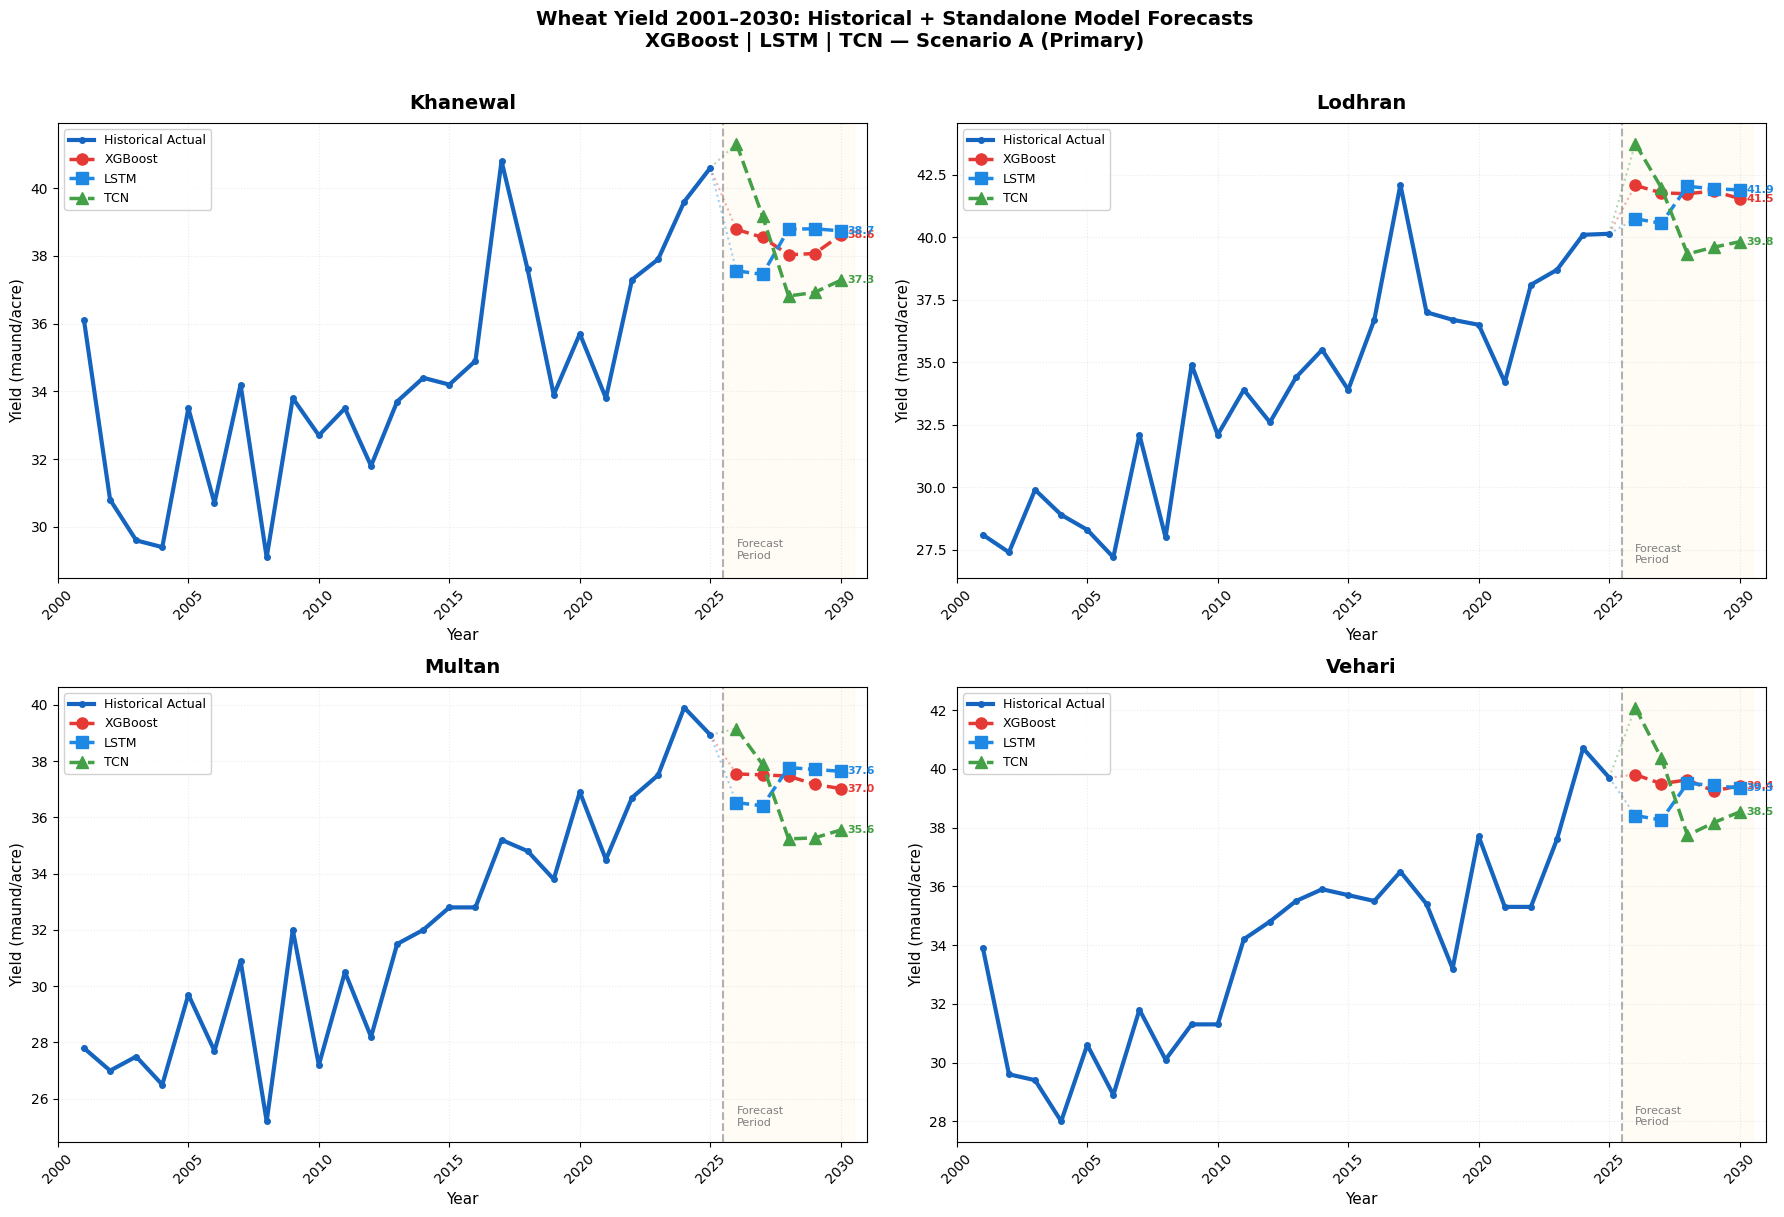

Saved: Plot1a_Timeline_Standalone_Models.png


In [ ]:
# ── CELL 13A — Plot 1a: Full Timeline — Standalone Models Only ───────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

standalone_styles = [
    ('XGB',  'XGBoost', '#E53935', 'o', 2.5),
    ('LSTM', 'LSTM',    '#1E88E5', 's', 2.5),
    ('TCN',  'TCN',     '#43A047', '^', 2.5),
]

for i, dist in enumerate(DISTRICTS):
    ax = axes[i]
    hd = hist[hist['District']==dist].sort_values('Year')
    fa = results_a[results_a['District']==dist].sort_values('Year')

    # Historical — thick blue solid
    ax.plot(hd['Year'], hd['Yield_maund_acre'],
            color='#1565C0', lw=3, marker='o', ms=4,
            label='Historical Actual', zorder=5)

    # Connect last historical point to first forecast point for each model
    last_hist_year = hd['Year'].max()
    last_hist_val  = hd[hd['Year']==last_hist_year]['Yield_maund_acre'].values[0]

    for col, lbl, clr, mrk, lw in standalone_styles:
        first_fut_val = fa[fa['Year']==2026][col].values[0]

        # Bridge line (thin, connecting 2025 to 2026)
        ax.plot([last_hist_year, 2026],
                [last_hist_val, first_fut_val],
                color=clr, lw=1.5, ls=':', alpha=0.4)

        # Forecast line — thick, distinct markers
        ax.plot(fa['Year'], fa[col],
                color=clr, lw=lw, marker=mrk, ms=8,
                ls='--', label=lbl, zorder=4)

        # Value label at 2030 only
        val_2030 = fa[fa['Year']==2030][col].values[0]
        ax.annotate(f'{val_2030:.1f}',
                    xy=(2030, val_2030), xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=8, color=clr, fontweight='bold', va='center')

    # Vertical divider
    ax.axvline(x=2025.5, color='gray', ls='--', alpha=0.6, lw=1.5)
    ax.axvspan(2025.5, 2030.5, alpha=0.04, color='orange')
    ax.text(2026, ax.get_ylim()[0]+0.5, 'Forecast\nPeriod',
            fontsize=8, color='gray', va='bottom', ha='left')

    ax.set_title(dist, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Yield (maund/acre)', fontsize=11)
    ax.set_xlim(2000, 2031)
    ax.grid(True, alpha=0.25, ls=':')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Wheat Yield 2001–2030: Historical + Standalone Model Forecasts\n'
             'XGBoost | LSTM | TCN — Scenario A (Primary)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot1a_Timeline_Standalone_Models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot1a_Timeline_Standalone_Models.png')

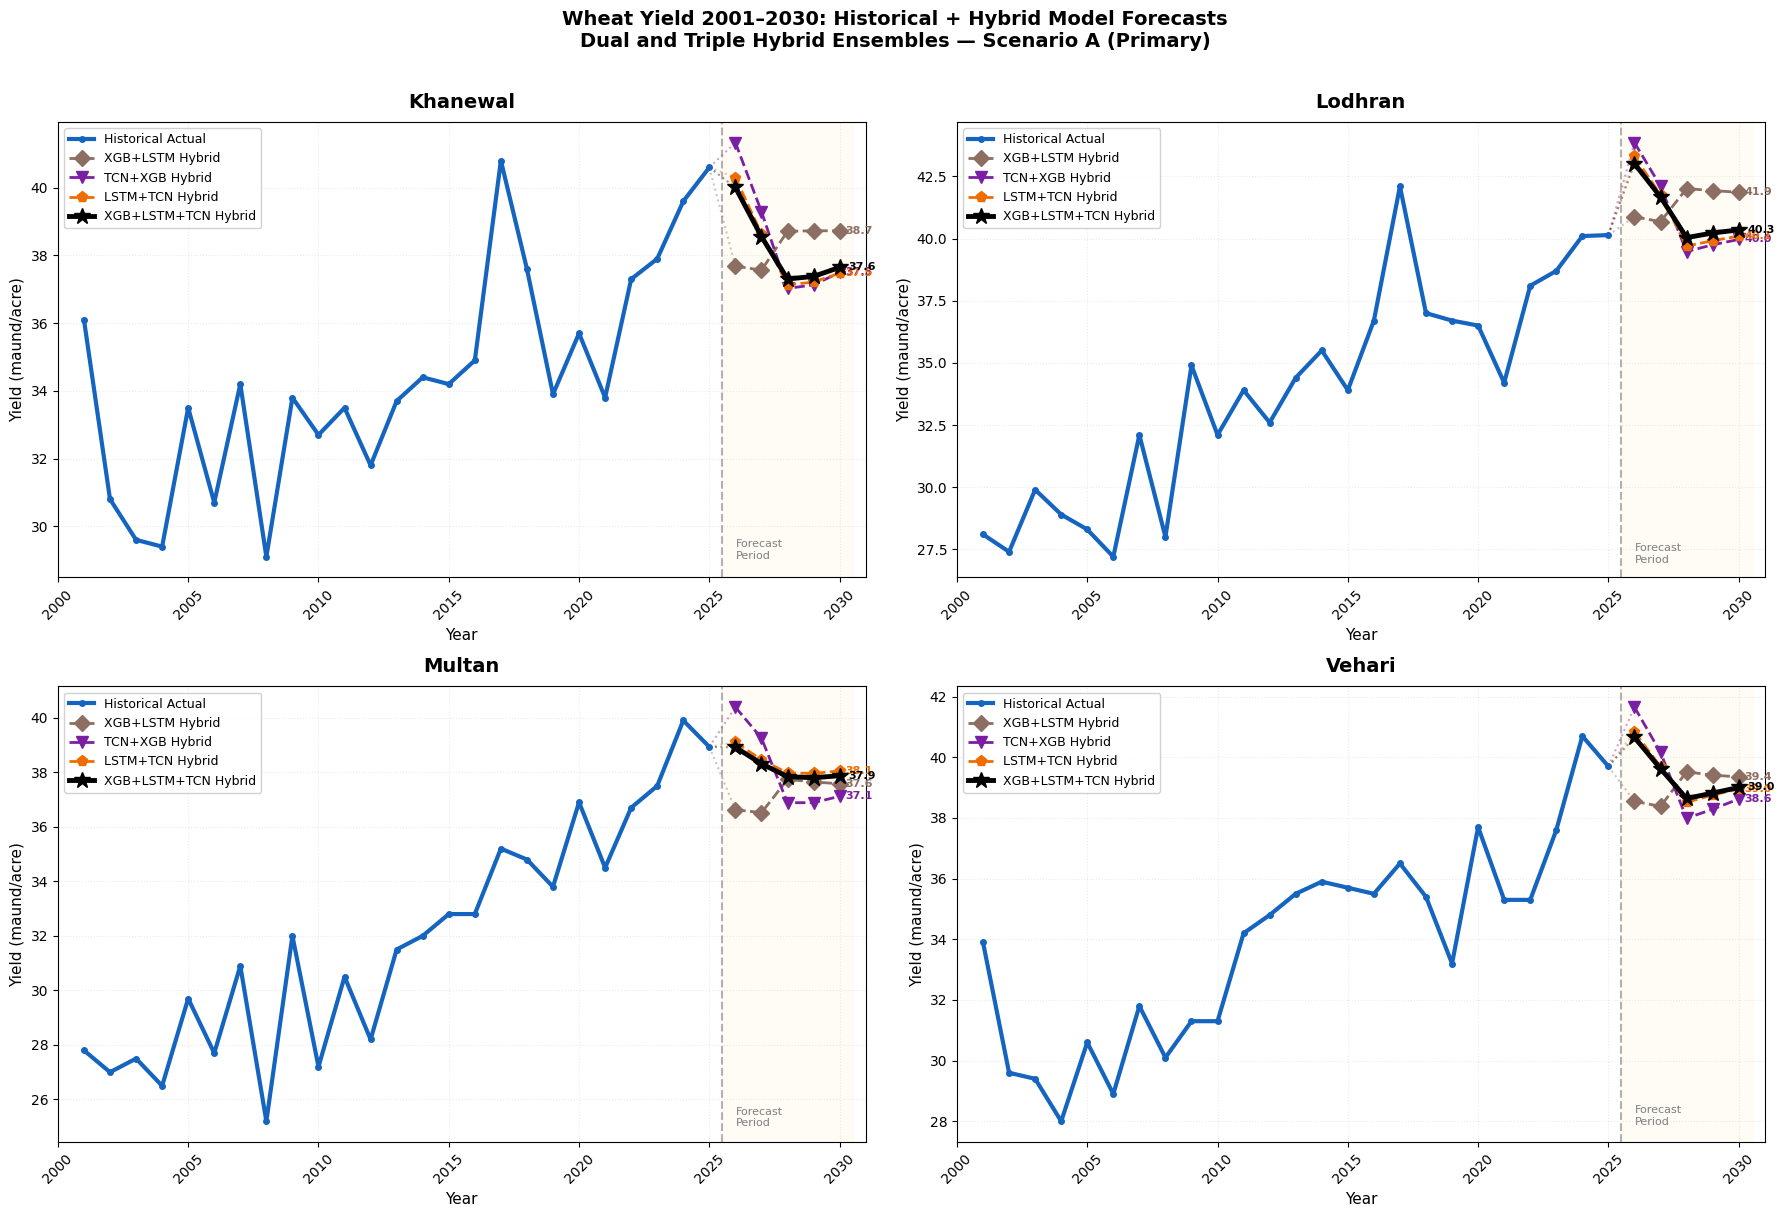

Saved: Plot1b_Timeline_Hybrid_Models.png


In [ ]:
# ── CELL 13B — Plot 1b: Full Timeline — Hybrid Models Only ──────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

hybrid_styles = [
    ('SERWI_XGB_LSTM', 'XGB+LSTM Hybrid',        '#8D6E63', 'D', 2.0),
    ('SERWI_TCN_XGB',  'TCN+XGB Hybrid',          '#7B1FA2', 'v', 2.0),
    ('SERWI_LSTM_TCN', 'LSTM+TCN Hybrid',         '#EF6C00', 'p', 2.0),
    ('SERWI_Triple',   'XGB+LSTM+TCN Hybrid', '#000000', '*', 3.5),
]

for i, dist in enumerate(DISTRICTS):
    ax = axes[i]
    hd = hist[hist['District']==dist].sort_values('Year')
    fa = results_a[results_a['District']==dist].sort_values('Year')

    last_hist_year = hd['Year'].max()
    last_hist_val  = hd[hd['Year']==last_hist_year]['Yield_maund_acre'].values[0]

    # Historical
    ax.plot(hd['Year'], hd['Yield_maund_acre'],
            color='#1565C0', lw=3, marker='o', ms=4,
            label='Historical Actual', zorder=5)

    for col, lbl, clr, mrk, lw in hybrid_styles:
        first_fut_val = fa[fa['Year']==2026][col].values[0]

        # Bridge
        ax.plot([last_hist_year, 2026],
                [last_hist_val, first_fut_val],
                color=clr, lw=1.5, ls=':', alpha=0.4)

        # Forecast
        ms   = 12 if 'Triple' in col else 8
        ls   = '-'  if 'Triple' in col else '--'
        zord =  5   if 'Triple' in col else 4
        ax.plot(fa['Year'], fa[col],
                color=clr, lw=lw, marker=mrk, ms=ms,
                ls=ls, label=lbl, zorder=zord)

        # Value label at 2030
        val_2030 = fa[fa['Year']==2030][col].values[0]
        offset   = 6 if 'Triple' in col else 4
        ax.annotate(f'{val_2030:.1f}',
                    xy=(2030, val_2030), xytext=(offset, 0),
                    textcoords='offset points',
                    fontsize=8, color=clr, fontweight='bold', va='center')

    # Forecast region
    ax.axvline(x=2025.5, color='gray', ls='--', alpha=0.6, lw=1.5)
    ax.axvspan(2025.5, 2030.5, alpha=0.04, color='orange')
    ax.text(2026, ax.get_ylim()[0]+0.5, 'Forecast\nPeriod',
            fontsize=8, color='gray', va='bottom', ha='left')

    ax.set_title(dist, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Yield (maund/acre)', fontsize=11)
    ax.set_xlim(2000, 2031)
    ax.grid(True, alpha=0.25, ls=':')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Wheat Yield 2001–2030: Historical + Hybrid Model Forecasts\n'
             'Dual and Triple Hybrid Ensembles — Scenario A (Primary)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot1b_Timeline_Hybrid_Models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot1b_Timeline_Hybrid_Models.png')

## CELL 14 — PLOT 2: All 7 Models Comparison (Scenario A)

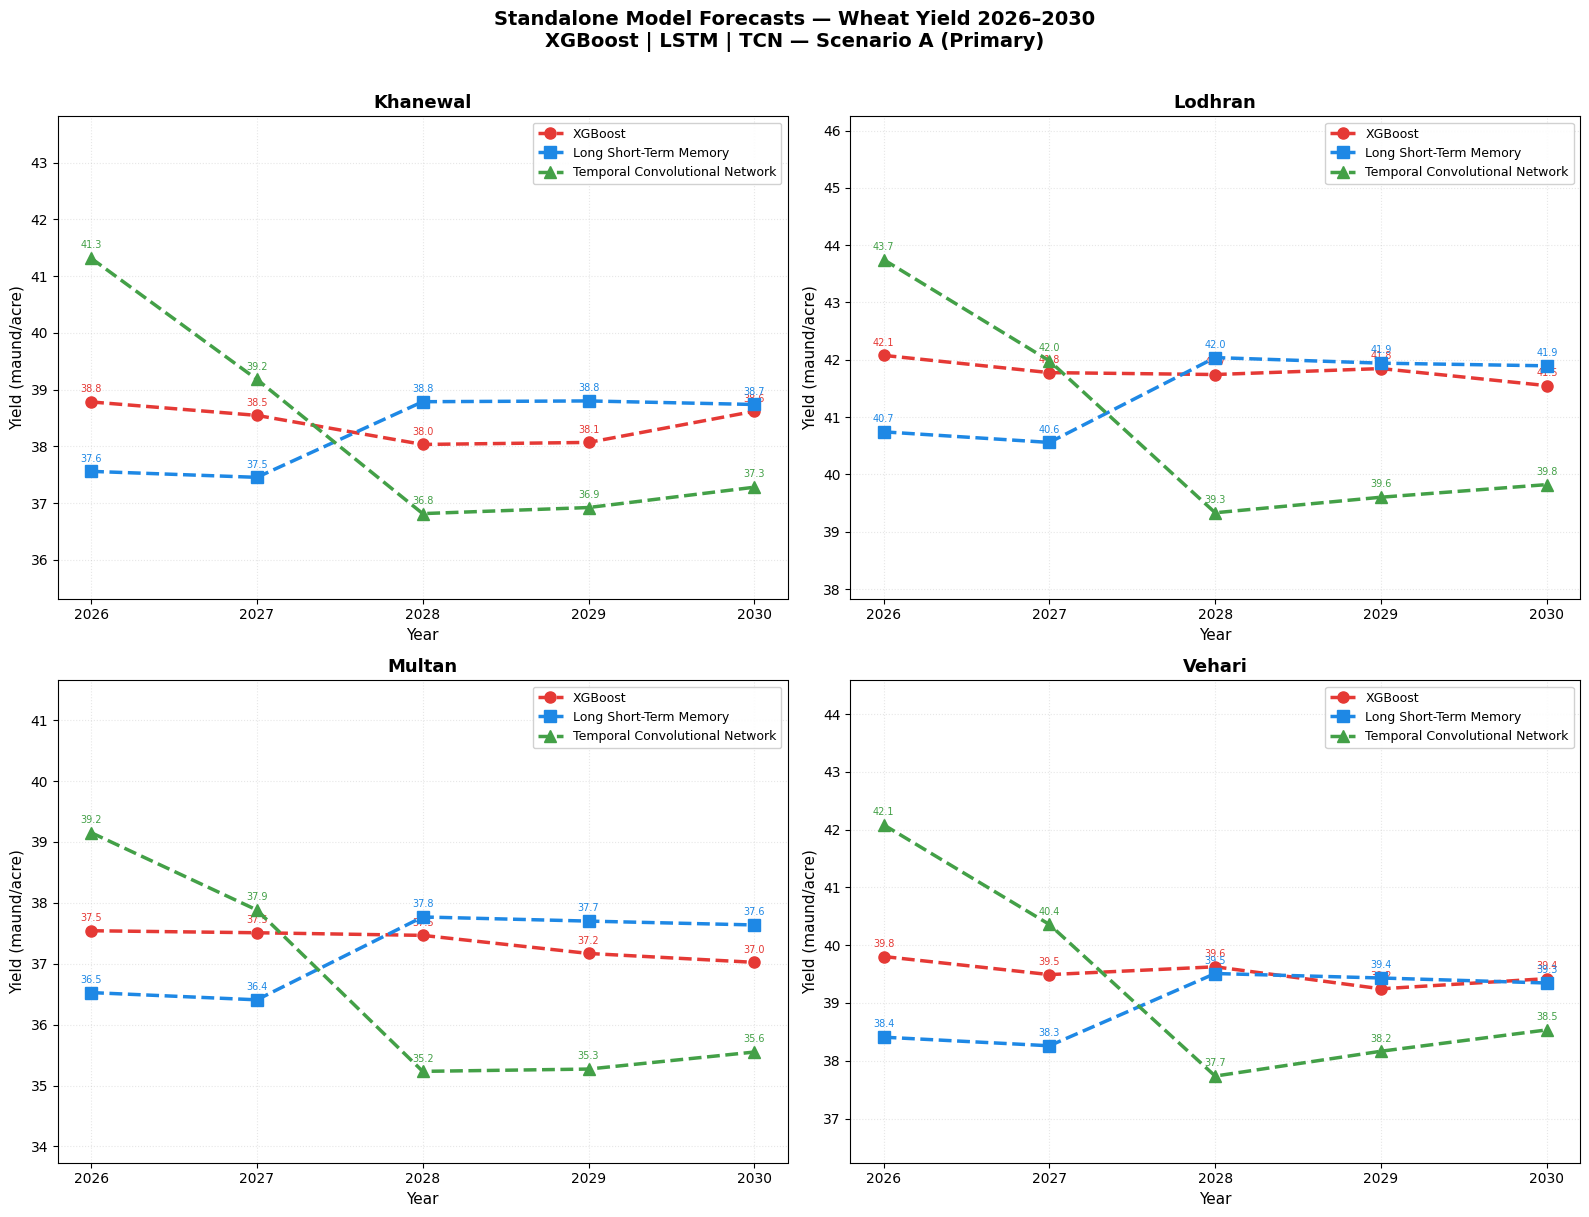

Saved: Plot2a_Forecast_Standalone_Models.png


In [ ]:
# ── CELL 14A — Plot 2a: Forecast 2026–2030 Standalone Models ─────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

standalone_styles = [
    ('XGB',  'XGBoost',                    '#E53935', 'o', 2.5),
    ('LSTM', 'Long Short-Term Memory',     '#1E88E5', 's', 2.5),
    ('TCN',  'Temporal Convolutional Network', '#43A047', '^', 2.5),
]

for i, dist in enumerate(DISTRICTS):
    ax = axes[i]
    d  = results_a[results_a['District']==dist].sort_values('Year')

    for col, lbl, clr, mrk, lw in standalone_styles:
        ax.plot(d['Year'], d[col],
                color=clr, lw=lw, marker=mrk, ms=8,
                ls='--', label=lbl, zorder=4)

        # Value label at each point
        for _, row in d.iterrows():
            ax.annotate(f"{row[col]:.1f}",
                        xy=(row['Year'], row[col]),
                        xytext=(0, 7), textcoords='offset points',
                        ha='center', fontsize=7, color=clr)

    ax.set_title(dist, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Yield (maund/acre)', fontsize=11)
    ax.set_xticks(FUTURE_YEARS)
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=9, framealpha=0.9)

    # Y axis padding
    ymin = min(results_a[results_a['District']==dist][['XGB','LSTM','TCN']].min()) - 1.5
    ymax = max(results_a[results_a['District']==dist][['XGB','LSTM','TCN']].max()) + 2.5
    ax.set_ylim(ymin, ymax)

plt.suptitle('Standalone Model Forecasts — Wheat Yield 2026–2030\n'
             'XGBoost | LSTM | TCN — Scenario A (Primary)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot2a_Forecast_Standalone_Models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot2a_Forecast_Standalone_Models.png')

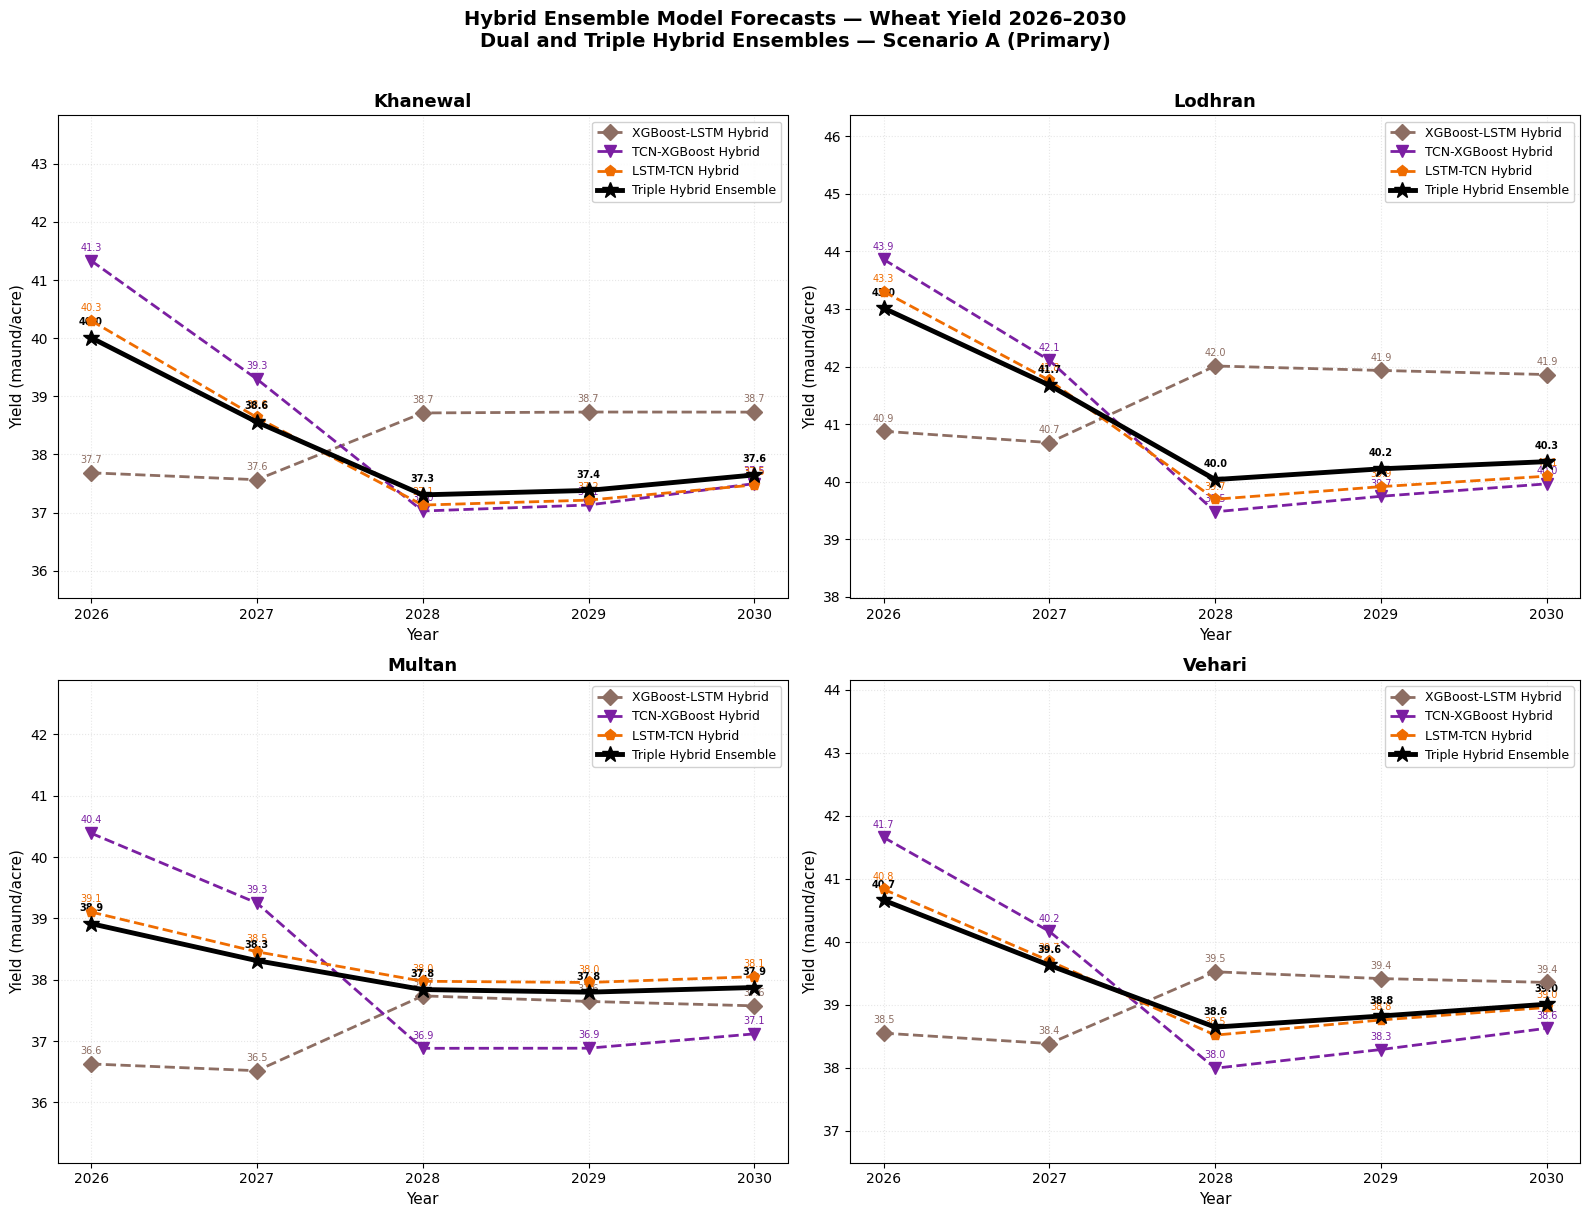

Saved: Plot2b_Forecast_Hybrid_Models.png


In [ ]:
# ── CELL 14B — Plot 2b: Forecast 2026–2030 Hybrid Models ─────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

hybrid_styles = [
    ('SERWI_XGB_LSTM', 'XGBoost-LSTM Hybrid',    '#8D6E63', 'D', 2.0),
    ('SERWI_TCN_XGB',  'TCN-XGBoost Hybrid',      '#7B1FA2', 'v', 2.0),
    ('SERWI_LSTM_TCN', 'LSTM-TCN Hybrid',         '#EF6C00', 'p', 2.0),
    ('SERWI_Triple',   'Triple Hybrid Ensemble',  '#000000', '*', 3.5),
]

for i, dist in enumerate(DISTRICTS):
    ax = axes[i]
    d  = results_a[results_a['District']==dist].sort_values('Year')

    for col, lbl, clr, mrk, lw in hybrid_styles:
        ms   = 12 if 'Triple' in col else 8
        ls   = '-'  if 'Triple' in col else '--'
        zord =  5   if 'Triple' in col else 4

        ax.plot(d['Year'], d[col],
                color=clr, lw=lw, marker=mrk, ms=ms,
                ls=ls, label=lbl, zorder=zord)

        # Value label at each point
        for _, row in d.iterrows():
            offset = 9 if 'Triple' in col else 7
            ax.annotate(f"{row[col]:.1f}",
                        xy=(row['Year'], row[col]),
                        xytext=(0, offset), textcoords='offset points',
                        ha='center', fontsize=7, color=clr,
                        fontweight='bold' if 'Triple' in col else 'normal')

    ax.set_title(dist, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Yield (maund/acre)', fontsize=11)
    ax.set_xticks(FUTURE_YEARS)
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=9, framealpha=0.9)

    hybrid_cols = ['SERWI_XGB_LSTM','SERWI_TCN_XGB','SERWI_LSTM_TCN','SERWI_Triple']
    ymin = results_a[results_a['District']==dist][hybrid_cols].min().min() - 1.5
    ymax = results_a[results_a['District']==dist][hybrid_cols].max().max() + 2.5
    ax.set_ylim(ymin, ymax)

plt.suptitle('Hybrid Ensemble Model Forecasts — Wheat Yield 2026–2030\n'
             'Dual and Triple Hybrid Ensembles — Scenario A (Primary)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot2b_Forecast_Hybrid_Models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot2b_Forecast_Hybrid_Models.png')

## CELL 15 — PLOT 3: District Bar Chart (SERWI Triple, Scenario A)

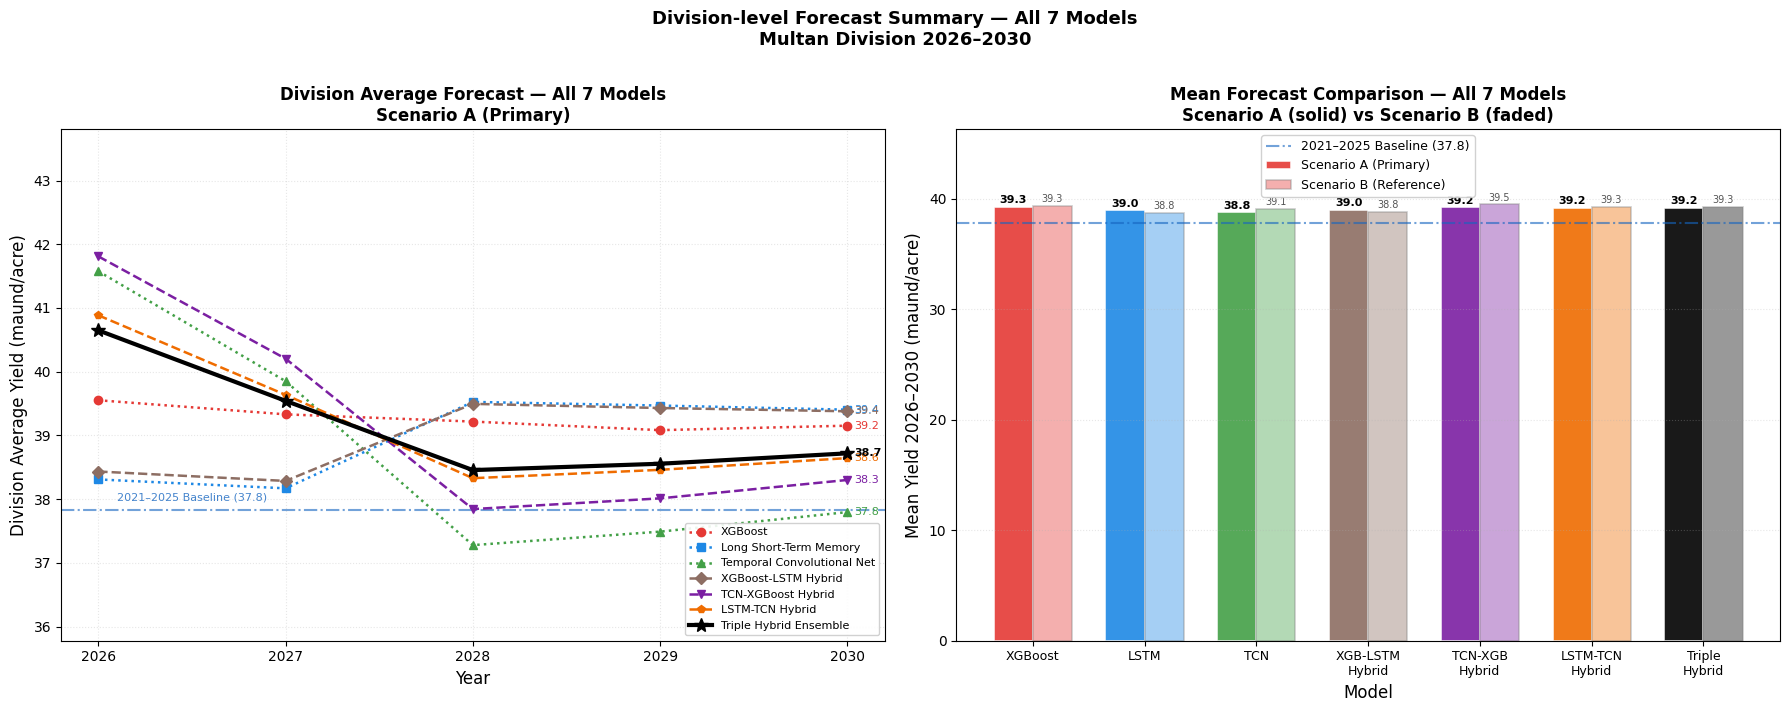

Saved: Plot3_Division_Average_All7_Models.png


In [ ]:
# ── CELL 15 — Plot 3: Division Average All 7 Models + Mean Comparison ────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left Panel: Division Average Per Year — All 7 Models ─────────────────
ax = axes[0]

model_styles = [
    ('XGB',           'XGBoost',                  '#E53935', 'o',  ':',  1.8),
    ('LSTM',          'Long Short-Term Memory',    '#1E88E5', 's',  ':',  1.8),
    ('TCN',           'Temporal Convolutional Net','#43A047', '^',  ':',  1.8),
    ('SERWI_XGB_LSTM','XGBoost-LSTM Hybrid',       '#8D6E63', 'D',  '--', 1.8),
    ('SERWI_TCN_XGB', 'TCN-XGBoost Hybrid',        '#7B1FA2', 'v',  '--', 1.8),
    ('SERWI_LSTM_TCN','LSTM-TCN Hybrid',            '#EF6C00', 'p',  '--', 1.8),
    ('SERWI_Triple',  'Triple Hybrid Ensemble',    '#000000', '*',  '-',  3.0),
]

for col, lbl, clr, mrk, ls, lw in model_styles:
    div_avg = results_a.groupby('Year')[col].mean()
    ms   = 10 if 'Triple' in col else 6
    zord =  5 if 'Triple' in col else 3
    ax.plot(div_avg.index, div_avg.values,
            color=clr, lw=lw, marker=mrk, ms=ms,
            ls=ls, label=lbl, zorder=zord)

    # Value label at 2030 only
    ax.annotate(f"{div_avg[2030]:.1f}",
                xy=(2030, div_avg[2030]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, color=clr, va='center',
                fontweight='bold' if 'Triple' in col else 'normal')

# Historical baseline reference line
hist_baseline = hist[hist['Year'] >= 2021]['Yield_maund_acre'].mean()
ax.axhline(y=hist_baseline, color='#1565C0', ls='-.', lw=1.5, alpha=0.6)
ax.text(2026.1, hist_baseline + 0.15,
        f'2021–2025 Baseline ({hist_baseline:.1f})',
        fontsize=8, color='#1565C0', alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Division Average Yield (maund/acre)', fontsize=12)
ax.set_title('Division Average Forecast — All 7 Models\nScenario A (Primary)',
             fontsize=12, fontweight='bold')
ax.set_xticks(FUTURE_YEARS)
ax.legend(fontsize=8, framealpha=0.9, loc='lower right')
ax.grid(True, alpha=0.3, ls=':')

# Set clean y limits
all_div_vals = [results_a.groupby('Year')[col].mean().values
                for col, *_ in model_styles]
ymin = min([v.min() for v in all_div_vals]) - 1.5
ymax = max([v.max() for v in all_div_vals]) + 2.0
ax.set_ylim(ymin, ymax)

# ── Right Panel: Mean 2026–2030 Bar Chart — All 7 Models, Both Scenarios ─
ax2 = axes[1]

model_display = [
    ('XGB',           'XGBoost',                  '#E53935'),
    ('LSTM',          'Long Short-Term Memory',    '#1E88E5'),
    ('TCN',           'Temporal Convolutional Net','#43A047'),
    ('SERWI_XGB_LSTM','XGBoost-LSTM Hybrid',       '#8D6E63'),
    ('SERWI_TCN_XGB', 'TCN-XGBoost Hybrid',        '#7B1FA2'),
    ('SERWI_LSTM_TCN','LSTM-TCN Hybrid',            '#EF6C00'),
    ('SERWI_Triple',  'Triple Hybrid Ensemble',    '#000000'),
]

short_names = ['XGBoost', 'LSTM', 'TCN',
               'XGB-LSTM\nHybrid', 'TCN-XGB\nHybrid',
               'LSTM-TCN\nHybrid', 'Triple\nHybrid']

means_a = [results_a[col].mean() for col, _, _ in model_display]
means_b = [results_b[col].mean() for col, _, _ in model_display]
colors  = [clr for _, _, clr in model_display]

x = np.arange(len(short_names))
w = 0.35

bars_a = ax2.bar(x - w/2, means_a, w,
                 color=colors, alpha=0.90,
                 edgecolor='white', linewidth=1.2,
                 label='Scenario A (Primary)')
bars_b = ax2.bar(x + w/2, means_b, w,
                 color=colors, alpha=0.40,
                 edgecolor='gray', linewidth=1.2,
                 label='Scenario B (Reference)')

# Value labels
for bar, val in zip(bars_a, means_a):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold')

for bar, val in zip(bars_b, means_b):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=7, color='#555')

# Baseline reference
ax2.axhline(y=hist_baseline, color='#1565C0', ls='-.', lw=1.5, alpha=0.6,
            label=f'2021–2025 Baseline ({hist_baseline:.1f})')

ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Mean Yield 2026–2030 (maund/acre)', fontsize=12)
ax2.set_title('Mean Forecast Comparison — All 7 Models\n'
              'Scenario A (solid) vs Scenario B (faded)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, fontsize=9)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.grid(True, axis='y', alpha=0.3, ls=':')
ax2.set_ylim(0, max(means_a) * 1.18)

plt.suptitle('Division-level Forecast Summary — All 7 Models\n'
             'Multan Division 2026–2030',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH + 'Plot3_Division_Average_All7_Models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot3_Division_Average_All7_Models.png')

## CELL 16 — PLOT 4: Division Average + Uncertainty Band

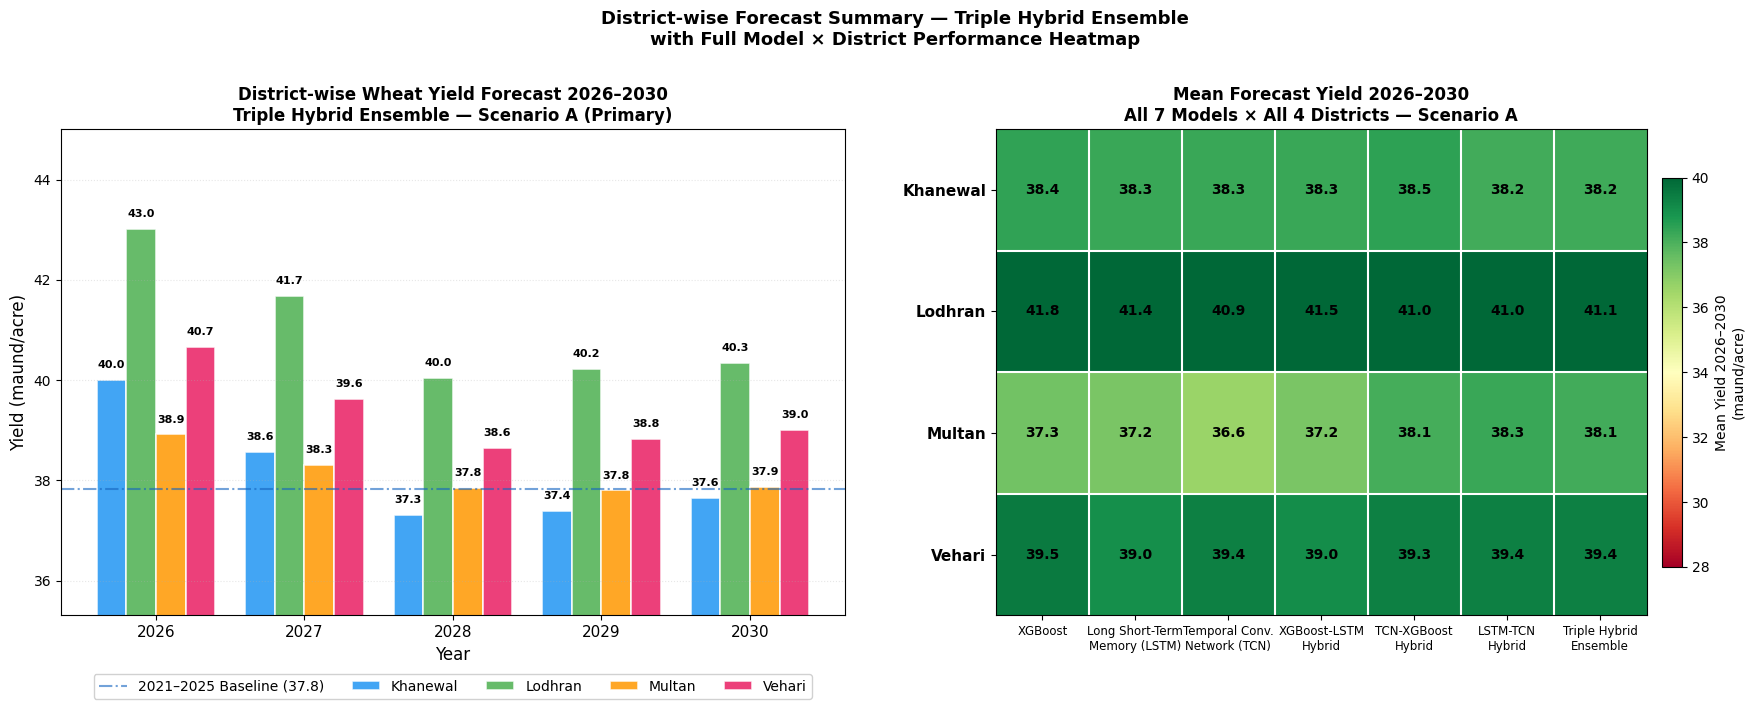

Saved: Plot4_District_Summary_Heatmap.png


In [ ]:
# ── CELL 16 — Plot 4: District-wise Bar Chart — Triple Hybrid + Heatmap ──

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left Panel: District Bar Chart — Triple Hybrid Ensemble ──────────────
ax = axes[0]

dist_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
x, width = np.arange(len(FUTURE_YEARS)), 0.2

for j, (dist, clr) in enumerate(zip(DISTRICTS, dist_colors)):
    vals = results_a[results_a['District']==dist].sort_values(
        'Year')['SERWI_Triple'].values
    bars = ax.bar(x + j*width, vals, width,
                  label=dist, color=clr,
                  alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

# Baseline reference
hist_baseline = hist[hist['Year']>=2021]['Yield_maund_acre'].mean()
ax.axhline(y=hist_baseline, color='#1565C0', ls='-.', lw=1.5, alpha=0.6,
           label=f'2021–2025 Baseline ({hist_baseline:.1f})')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Yield (maund/acre)', fontsize=12)
ax.set_title('District-wise Wheat Yield Forecast 2026–2030\n'
             'Triple Hybrid Ensemble — Scenario A (Primary)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(FUTURE_YEARS, fontsize=11)

# Fix: move legend below the plot to avoid covering bars
ax.legend(fontsize=10, framealpha=0.9,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.12),
          ncol=5,
          borderaxespad=0.)

ax.grid(True, axis='y', alpha=0.3, ls=':')

# Y axis starts from reasonable value not 0 — avoid empty space
ymin = results_a['SERWI_Triple'].min() - 2
ymax = results_a['SERWI_Triple'].max() + 2
ax.set_ylim(ymin, ymax)

# ── Right Panel: Heatmap — All 7 Models × All 4 Districts ────────────────
ax2 = axes[1]

model_cols   = ['XGB','LSTM','TCN',
                'SERWI_XGB_LSTM','SERWI_TCN_XGB',
                'SERWI_LSTM_TCN','SERWI_Triple']
model_labels = ['XGBoost',
                'Long Short-Term\nMemory (LSTM)',
                'Temporal Conv.\nNetwork (TCN)',
                'XGBoost-LSTM\nHybrid',
                'TCN-XGBoost\nHybrid',
                'LSTM-TCN\nHybrid',
                'Triple Hybrid\nEnsemble']

# Mean across 2026-2030 per district per model
table_data = np.zeros((len(DISTRICTS), len(model_cols)))
for i, dist in enumerate(DISTRICTS):
    for j, col in enumerate(model_cols):
        table_data[i, j] = results_a[
            results_a['District']==dist][col].mean()

im = ax2.imshow(table_data, cmap='RdYlGn',
                aspect='auto', vmin=28, vmax=40)

ax2.set_xticks(range(len(model_cols)))
ax2.set_xticklabels(model_labels, fontsize=8.5)
ax2.set_yticks(range(len(DISTRICTS)))
ax2.set_yticklabels(DISTRICTS, fontsize=11, fontweight='bold')

# Cell value annotations
for i in range(len(DISTRICTS)):
    for j in range(len(model_cols)):
        val = table_data[i, j]
        text_color = 'black' if val > 32 else 'white'
        ax2.text(j, i, f'{val:.1f}',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold',
                 color=text_color)

# Colorbar
cbar = plt.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
cbar.set_label('Mean Yield 2026–2030\n(maund/acre)', fontsize=10)

ax2.set_title('Mean Forecast Yield 2026–2030\n'
              'All 7 Models × All 4 Districts — Scenario A',
              fontsize=12, fontweight='bold')

# Grid lines
for edge in range(1, len(model_cols)):
    ax2.axvline(x=edge-0.5, color='white', lw=1.5)
for edge in range(1, len(DISTRICTS)):
    ax2.axhline(y=edge-0.5, color='white', lw=1.5)

plt.suptitle('District-wise Forecast Summary — Triple Hybrid Ensemble\n'
             'with Full Model × District Performance Heatmap',
             fontsize=13, fontweight='bold', y=1.01)

# Extra bottom space for legend
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot4_District_Summary_Heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot4_District_Summary_Heatmap.png')

## CELL 17 — PLOT 5: Scenario A vs B Comparison Per District

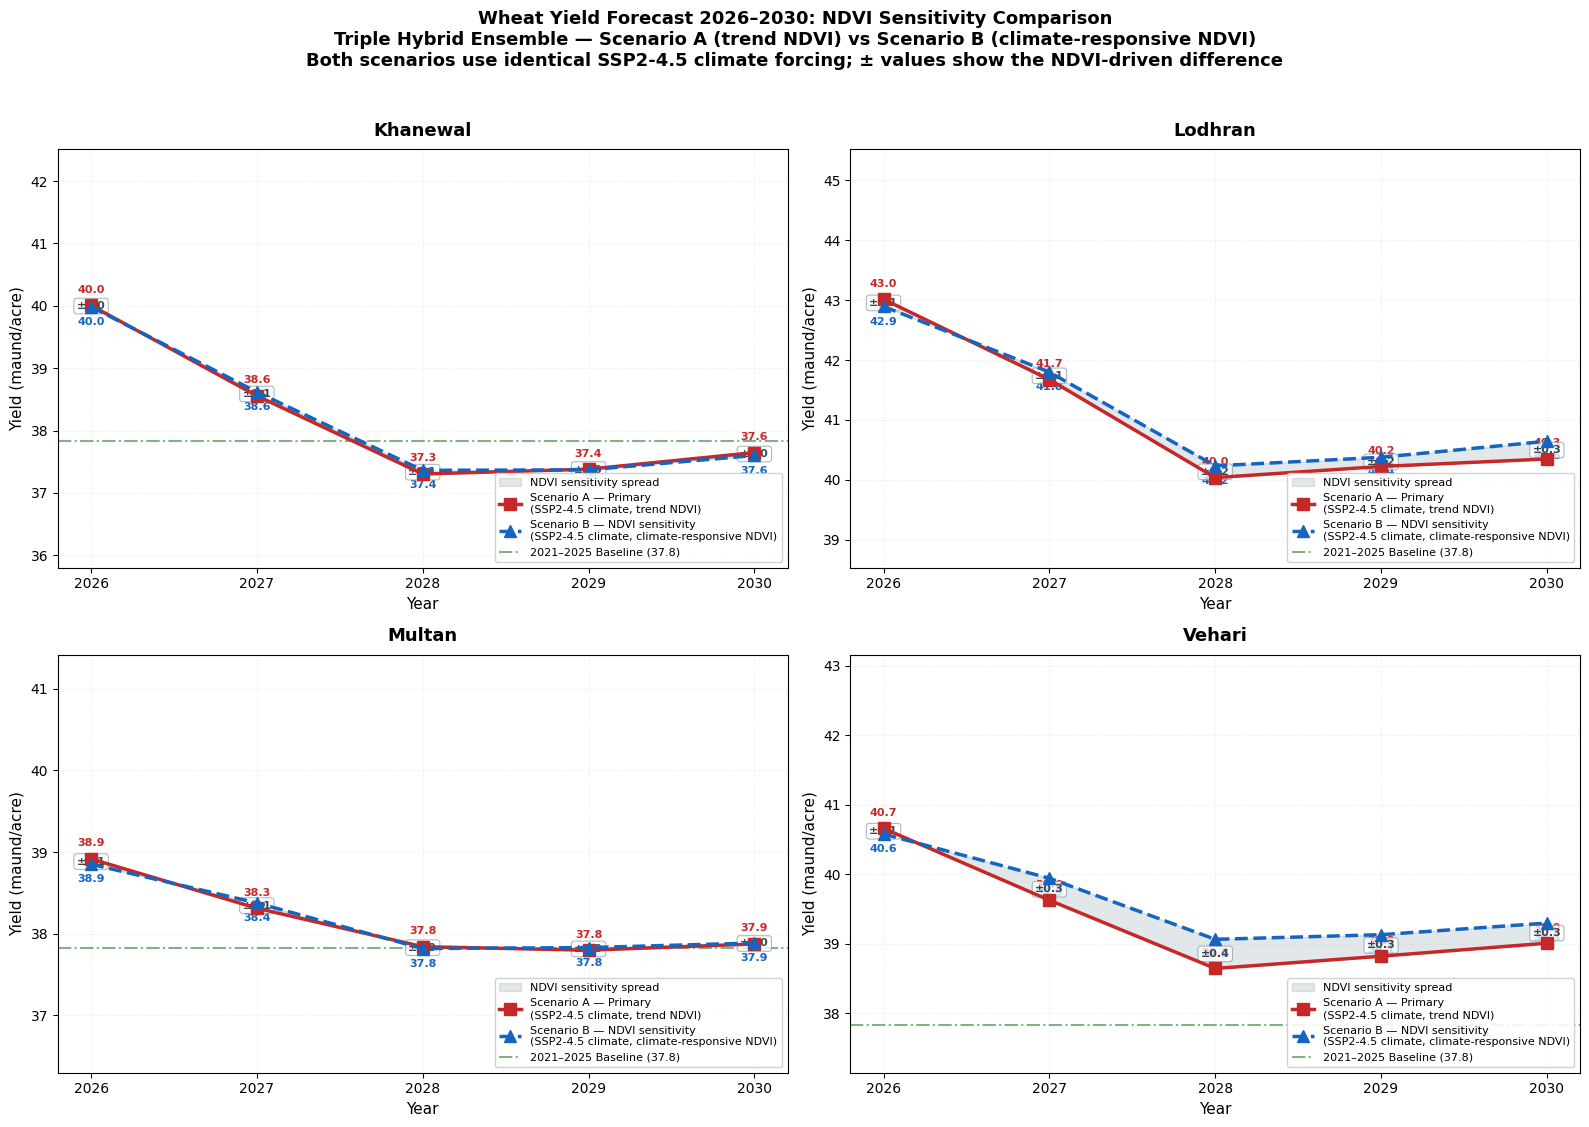

Saved: Plot5_ScenarioA_vs_B_Comparison.png


In [ ]:
# ── CELL 17 — Plot 5b: Per District Scenario A vs B — Triple Hybrid ──────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

hist_baseline = hist[hist['Year']>=2021]['Yield_maund_acre'].mean()

for i, dist in enumerate(DISTRICTS):
    ax  = axes[i]
    fa  = results_a[results_a['District']==dist].sort_values('Year')
    fb  = results_b[results_b['District']==dist].sort_values('Year')

    # Sensitivity band first (behind lines)
    ax.fill_between(fa['Year'], fa['SERWI_Triple'], fb['SERWI_Triple'],
                    alpha=0.18, color='#607D8B', label='NDVI sensitivity spread')

    # Scenario A
    ax.plot(fa['Year'], fa['SERWI_Triple'],
            color='#C62828', lw=2.5, marker='s', ms=8,
            label='Scenario A — Primary\n(SSP2-4.5 climate, trend NDVI)',
            zorder=4)

    # Scenario B
    ax.plot(fb['Year'], fb['SERWI_Triple'],
            color='#1565C0', lw=2.5, marker='^', ms=8,
            ls='--',
            label='Scenario B — NDVI sensitivity\n(SSP2-4.5 climate, climate-responsive NDVI)',
            zorder=4)

    # Value labels on Scenario A line
    for _, row in fa.iterrows():
        ax.annotate(f"{row['SERWI_Triple']:.1f}",
                    xy=(row['Year'], row['SERWI_Triple']),
                    xytext=(0, 9), textcoords='offset points',
                    ha='center', fontsize=8,
                    color='#C62828', fontweight='bold')

    # Value labels on Scenario B line
    for _, row in fb.iterrows():
        ax.annotate(f"{row['SERWI_Triple']:.1f}",
                    xy=(row['Year'], row['SERWI_Triple']),
                    xytext=(0, -13), textcoords='offset points',
                    ha='center', fontsize=8,
                    color='#1565C0', fontweight='bold')

    # Scenario difference annotations (midpoint)
    for yr in FUTURE_YEARS:
        va  = fa[fa['Year']==yr]['SERWI_Triple'].values[0]
        vb  = fb[fb['Year']==yr]['SERWI_Triple'].values[0]
        mid = (va + vb) / 2
        rng = abs(va - vb)
        ax.annotate(f'±{rng:.1f}',
                    xy=(yr, mid),
                    ha='center', va='center', fontsize=8,
                    color='#37474F', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25',
                              facecolor='white',
                              alpha=0.75,
                              edgecolor='#90A4AE',
                              linewidth=0.8))

    # Baseline reference
    ax.axhline(y=hist_baseline, color='#2E7D32', ls='-.', lw=1.5,
               alpha=0.6, label=f'2021–2025 Baseline ({hist_baseline:.1f})')

    # Y axis limits with padding
    all_vals = pd.concat([fa['SERWI_Triple'], fb['SERWI_Triple']])
    ax.set_ylim(all_vals.min() - 1.5, all_vals.max() + 2.5)

    ax.set_title(dist, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Yield (maund/acre)', fontsize=11)
    ax.set_xticks(FUTURE_YEARS)
    ax.grid(True, alpha=0.25, ls=':')
    ax.legend(fontsize=8, framealpha=0.9, loc='lower right')

plt.suptitle('Wheat Yield Forecast 2026–2030: NDVI Sensitivity Comparison\n'
             'Triple Hybrid Ensemble — Scenario A (trend NDVI) vs Scenario B (climate-responsive NDVI)\n'
             'Both scenarios use identical SSP2-4.5 climate forcing; ± values show the NDVI-driven difference',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot5_ScenarioA_vs_B_Comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot5_ScenarioA_vs_B_Comparison.png')

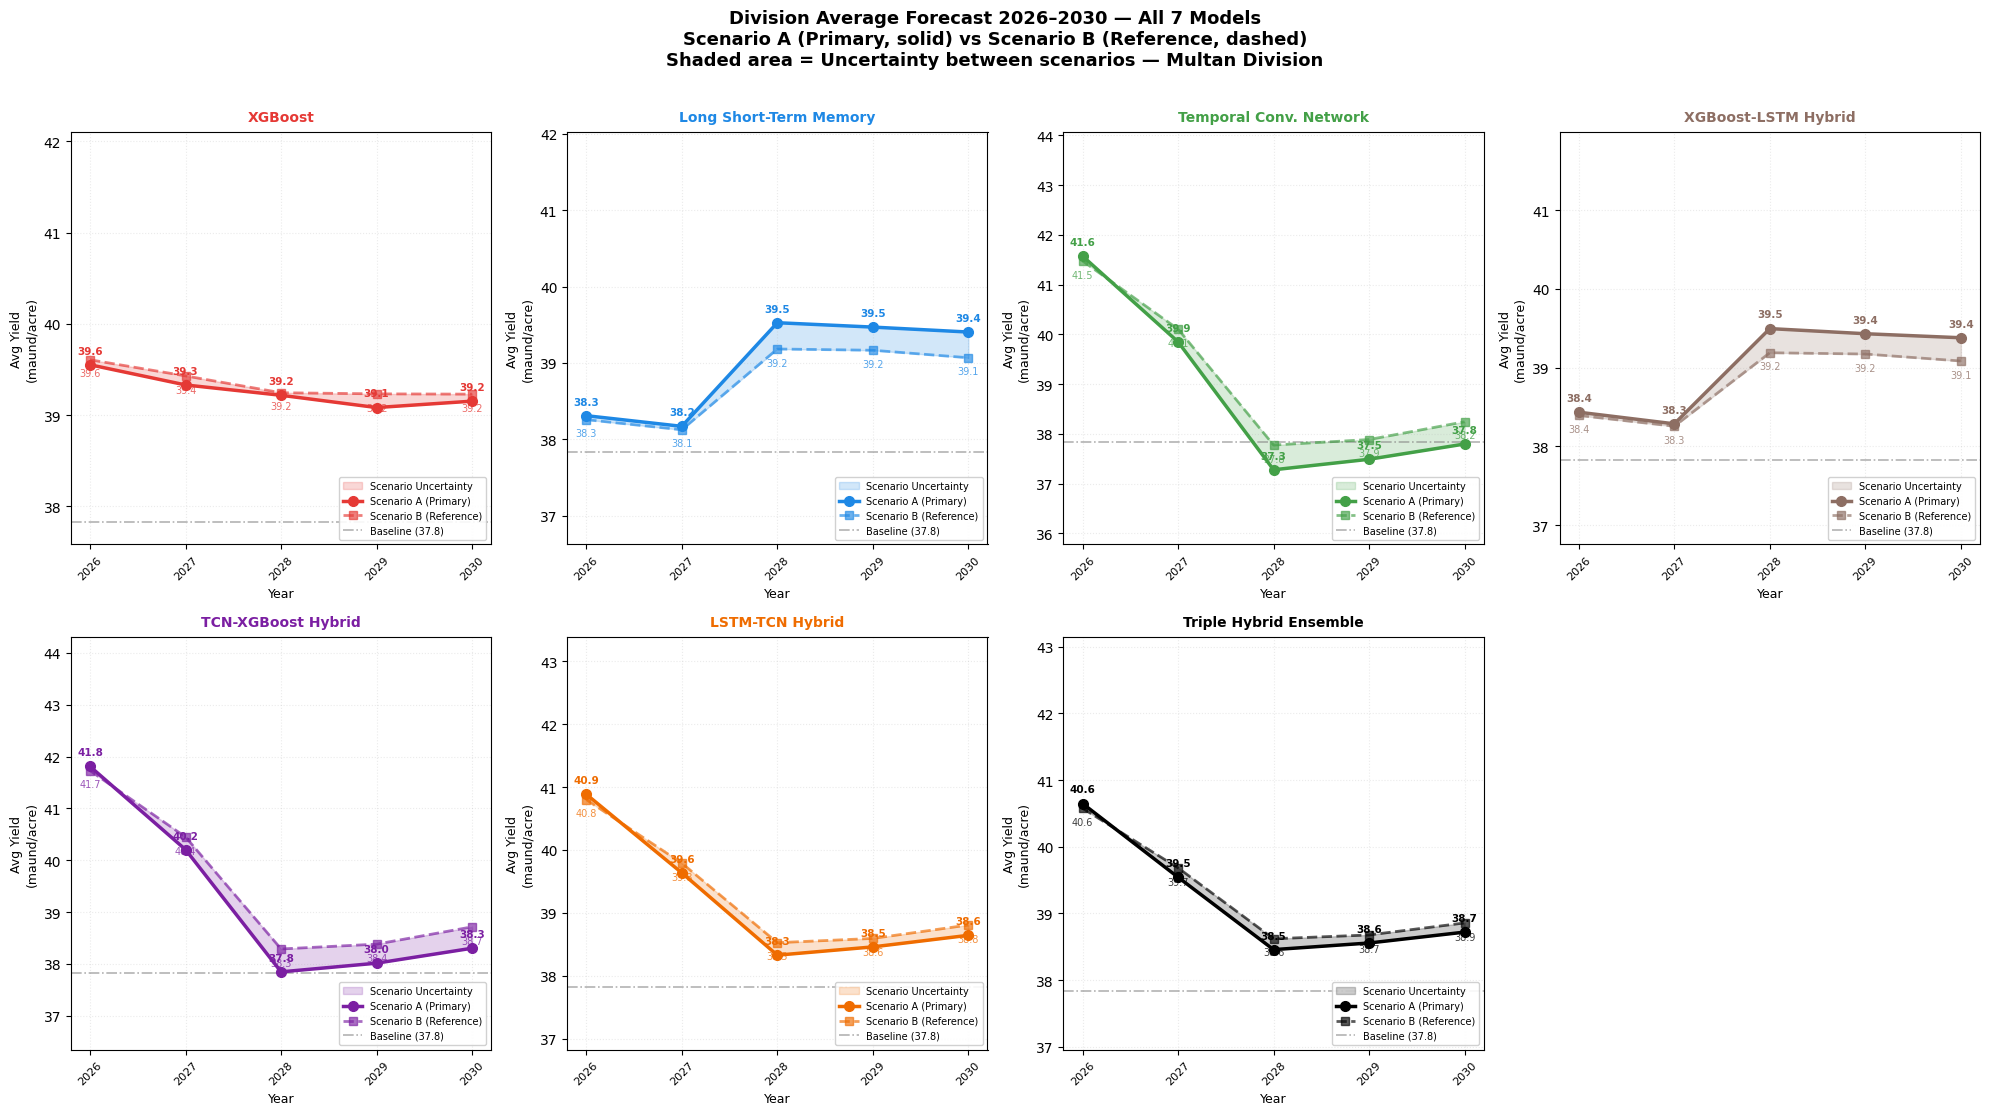

Saved: Plot5_ScenA_vs_ScenB_All7_Models.png


In [ ]:
# ── CELL 17B — Plot 5: Division Average ScenA vs ScenB — All 7 Models ────

fig, axes = plt.subplots(2, 4, figsize=(20, 11))
axes = axes.flatten()

model_styles = [
    ('XGB',           'XGBoost',                  '#E53935'),
    ('LSTM',          'Long Short-Term Memory',    '#1E88E5'),
    ('TCN',           'Temporal Conv. Network',    '#43A047'),
    ('SERWI_XGB_LSTM','XGBoost-LSTM Hybrid',       '#8D6E63'),
    ('SERWI_TCN_XGB', 'TCN-XGBoost Hybrid',        '#7B1FA2'),
    ('SERWI_LSTM_TCN','LSTM-TCN Hybrid',            '#EF6C00'),
    ('SERWI_Triple',  'Triple Hybrid Ensemble',    '#000000'),
]

hist_baseline = hist[hist['Year']>=2021]['Yield_maund_acre'].mean()

for i, (col, lbl, clr) in enumerate(model_styles):
    ax = axes[i]

    div_a = results_a.groupby('Year')[col].mean()
    div_b = results_b.groupby('Year')[col].mean()

    # Uncertainty band between scenarios
    ax.fill_between(div_a.index, div_a.values, div_b.values,
                    alpha=0.20, color=clr, label='Scenario Uncertainty')

    # Scenario A — solid
    ax.plot(div_a.index, div_a.values,
            color=clr, lw=2.5, marker='o', ms=7,
            ls='-', label='Scenario A (Primary)', zorder=4)

    # Scenario B — dashed same color
    ax.plot(div_b.index, div_b.values,
            color=clr, lw=2, marker='s', ms=6,
            ls='--', alpha=0.65, label='Scenario B (Reference)', zorder=4)

    # Value labels ScenA
    for yr, va in div_a.items():
        ax.annotate(f'{va:.1f}',
                    xy=(yr, va), xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', fontsize=7.5,
                    color=clr, fontweight='bold')

    # Value labels ScenB
    for yr, vb in div_b.items():
        ax.annotate(f'{vb:.1f}',
                    xy=(yr, vb), xytext=(0, -12),
                    textcoords='offset points',
                    ha='center', fontsize=7,
                    color=clr, alpha=0.75)

    # Baseline
    ax.axhline(y=hist_baseline, color='gray', ls='-.', lw=1.2,
               alpha=0.6, label=f'Baseline ({hist_baseline:.1f})')

    # Y limits
    all_vals = pd.concat([div_a, div_b])
    ax.set_ylim(all_vals.min()-1.5, all_vals.max()+2.5)

    ax.set_title(lbl, fontsize=10, fontweight='bold',
                 color=clr if col != 'SERWI_Triple' else 'black',
                 pad=8)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Avg Yield\n(maund/acre)', fontsize=9)
    ax.set_xticks(FUTURE_YEARS)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.25, ls=':')
    ax.legend(fontsize=7, framealpha=0.9, loc='lower right')

# Hide the 8th empty subplot
axes[7].set_visible(False)

plt.suptitle('Division Average Forecast 2026–2030 — All 7 Models\n'
             'Scenario A (Primary, solid) vs Scenario B (Reference, dashed)\n'
             'Shaded area = Uncertainty between scenarios — Multan Division',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot5_ScenA_vs_ScenB_All7_Models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot5_ScenA_vs_ScenB_All7_Models.png')

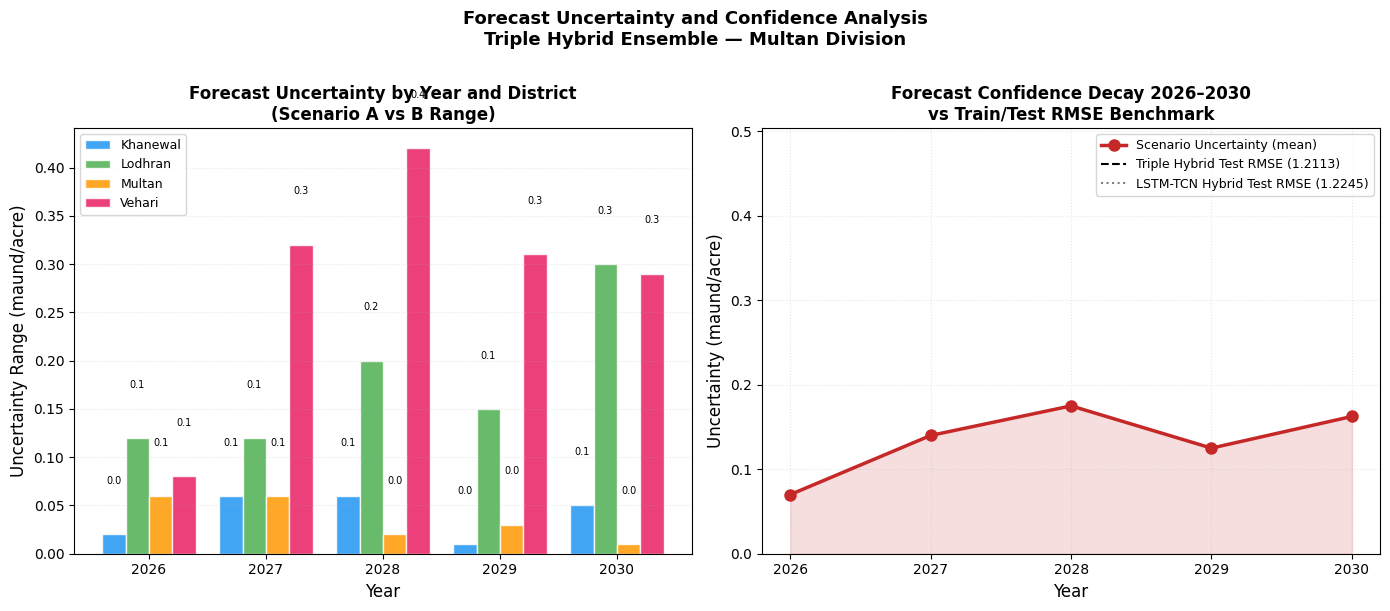

Saved: Plot6_Confidence_Decay_Uncertainty.png


In [ ]:
# ── NEW CELL — Plot 6: Confidence Decay Over Time ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Uncertainty range per year per district
years_list = FUTURE_YEARS
dist_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
x = np.arange(len(years_list))
width = 0.2

ax = axes[0]
for j, (dist, clr) in enumerate(zip(DISTRICTS, dist_colors)):
    vals = unc_df[unc_df['District']==dist].sort_values('Year')['Range'].values
    ax.bar(x + j*width, vals, width, label=dist, color=clr, alpha=0.85, edgecolor='white')
    for i, (bar_x, val) in enumerate(zip(x + j*width, vals)):
        ax.text(bar_x, val+0.05, f'{val:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Uncertainty Range (maund/acre)', fontsize=12)
ax.set_title('Forecast Uncertainty by Year and District\n(Scenario A vs B Range)', fontsize=12, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(FUTURE_YEARS)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3, ls=':')

# Right: Division average uncertainty + model RMSE reference lines
ax2 = axes[1]
div_unc = unc_df.groupby('Year')['Range'].mean().values
ax2.plot(FUTURE_YEARS, div_unc, color='#C62828', lw=2.5,
         marker='o', ms=8, label='Scenario Uncertainty (mean)')
ax2.fill_between(FUTURE_YEARS, 0, div_unc, alpha=0.15, color='#C62828')

# Add RMSE reference lines from train/test phase
rmse_triple  = 1.2113
rmse_lstmtcn = 1.2245
ax2.axhline(y=rmse_triple,  color='black', ls='--', lw=1.5,
            label=f'Triple Hybrid Test RMSE ({rmse_triple})')
ax2.axhline(y=rmse_lstmtcn, color='gray',  ls=':', lw=1.5,
            label=f'LSTM-TCN Hybrid Test RMSE ({rmse_lstmtcn})')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Uncertainty (maund/acre)', fontsize=12)
ax2.set_title('Forecast Confidence Decay 2026–2030\nvs Train/Test RMSE Benchmark', fontsize=12, fontweight='bold')
ax2.set_xticks(FUTURE_YEARS)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, ls=':')
ax2.set_ylim(0, unc_df['Range'].max() * 1.2)

plt.suptitle('Forecast Uncertainty and Confidence Analysis\n'
             'Triple Hybrid Ensemble — Multan Division',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FORECAST_PATH+'Plot6_Confidence_Decay_Uncertainty.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Plot6_Confidence_Decay_Uncertainty.png')

## CELL 18 — Save All Results to Drive

In [ ]:
# ── CELL 18 — Save All Results to Drive (self-contained) ────────────────

pred_cols = ['XGB','LSTM','TCN','SERWI_XGB_LSTM','SERWI_TCN_XGB','SERWI_LSTM_TCN','SERWI_Triple']
results_a[pred_cols] = results_a[pred_cols].round(3)
results_b[pred_cols] = results_b[pred_cols].round(3)

# ── Save prediction results ─────────────────────────────────────────────
results_a.to_csv(FORECAST_PATH+'Forecast_ScenarioA_Primary.csv', index=False)
results_b.to_csv(FORECAST_PATH+'Forecast_ScenarioB_Reference.csv', index=False)
pd.concat([results_a, results_b]).to_csv(FORECAST_PATH+'Forecast_ALL_Scenarios.csv', index=False)

# ── Build & save FULL TIMELINE (historical 2001–2025 + Scenario A 2026–2030) ──
CONV = 40/0.4047
hist_tl = hist[['Year','District','Yield_maund_acre']].copy()
hist_tl['Yield_kg_ha'] = hist_tl['Yield_maund_acre'] * CONV
hist_tl['Scenario']    = 'Historical'
hist_tl = hist_tl[['Year','District','Yield_kg_ha','Scenario']]

proj_tl = results_a[['Year','District','SERWI_Triple']].copy()
proj_tl['Yield_kg_ha'] = proj_tl['SERWI_Triple'] * CONV
proj_tl['Scenario']    = 'ScenarioA_Primary'
proj_tl = proj_tl[['Year','District','Yield_kg_ha','Scenario']]

full_timeline = pd.concat([hist_tl, proj_tl]).sort_values(['District','Year']).reset_index(drop=True)
full_timeline.to_csv(FORECAST_PATH+'Full_Timeline_2001_2030_ScenarioA.csv', index=False)

# ── Build & save UNCERTAINTY TABLE (Scenario A vs B spread per district) ──
unc_rows = []
for d in DISTRICTS:
    a = results_a[results_a.District==d].groupby('Year')['SERWI_Triple'].mean()*CONV
    b = results_b[results_b.District==d].groupby('Year')['SERWI_Triple'].mean()*CONV
    unc_rows.append({
        'District':      d,
        'ScenA_mean':    round(a.mean(),1),
        'ScenB_mean':    round(b.mean(),1),
        'ScenA_min':     round(a.min(),1),
        'ScenA_max':     round(a.max(),1),
        'A_minus_B':     round(a.mean()-b.mean(),1),
        'A_minus_B_pct': round((a.mean()-b.mean())/b.mean()*100,1),
    })
unc_df = pd.DataFrame(unc_rows)
unc_df.to_csv(FORECAST_PATH+'Forecast_Uncertainty_Table.csv', index=False)

# ── Save hardcoded SERWI weights used for forecasting ───────────────────
wr = []
for dist in DISTRICTS:
    w_tx = tcn_xgb_weights[dist]; w_lt = lstm_tcn_weights[dist]
    wr.append({
        'District':        dist,
        'W_TCN_tx':        w_tx['tcn_w'], 'W_XGB_tx': w_tx['xgb_w'], 'Bias_tx': w_tx['bias'],
        'Global_TCN_tx':   TCN_XGB_GLOBAL_TCN, 'Global_SERWI_tx': TCN_XGB_GLOBAL_SERWI,
        'W_LSTM_lt':       w_lt['lstm_w'], 'W_TCN_lt': w_lt['tcn_w'], 'Bias_lt': w_lt['bias'],
        'Global_TCN_lt':   LSTM_TCN_GLOBAL_TCN, 'Global_SERWI_lt': LSTM_TCN_GLOBAL_SERWI,
        'W_XGB_xl':        XGB_LSTM_W_XGB, 'W_LSTM_xl': XGB_LSTM_W_LSTM,
        'Bias_correction': dist_bias_correction[dist]
    })
pd.DataFrame(wr).to_csv(FORECAST_PATH+'Forecast_SERWI_Weights.csv', index=False)

print('ALL SAVED TO Wheat_Future_Forecast/')
for f in ['Forecast_ScenarioA_Primary.csv','Forecast_ScenarioB_Reference.csv',
          'Forecast_ALL_Scenarios.csv','Forecast_SERWI_Weights.csv',
          'Forecast_Uncertainty_Table.csv','Full_Timeline_2001_2030_ScenarioA.csv']:
    print('  '+f)

ALL SAVED TO Wheat_Future_Forecast/
  Forecast_ScenarioA_Primary.csv
  Forecast_ScenarioB_Reference.csv
  Forecast_ALL_Scenarios.csv
  Forecast_SERWI_Weights.csv
  Forecast_Uncertainty_Table.csv
  Full_Timeline_2001_2030_ScenarioA.csv


## CELL 19 — Final Summary Statistics

In [ ]:
print('='*60)
print('FINAL SUMMARY — SERWI TRIPLE (Scenario A Primary)')
print('='*60)
baseline=hist[hist['Year']>=2021].groupby('District')['Yield_maund_acre'].mean().round(2)
print('\nHistorical baseline 2021-2025 per district:')
print(baseline.to_string())
print()
print('Forecast 2026-2030 per district:')
for dist in DISTRICTS:
    d=results_a[results_a['District']==dist]
    base=baseline[dist]; fmean=d['SERWI_Triple'].mean()
    fmin=d['SERWI_Triple'].min(); fmax=d['SERWI_Triple'].max()
    chg=((fmean-base)/base)*100
    print(f'  {dist}: Mean={fmean:.2f} Range=[{fmin:.2f}-{fmax:.2f}] Change vs baseline: {"+" if chg>0 else ""}{chg:.1f}%')
print()
print('Division average per year:')
for yr in FUTURE_YEARS:
    avg=results_a[results_a['Year']==yr]['SERWI_Triple'].mean()
    print(f'  {yr}: {avg:.2f} maund/acre')
div_base=hist[hist['Year']>=2021]['Yield_maund_acre'].mean()
div_fore=results_a['SERWI_Triple'].mean()
print(f'\nDivision baseline: {div_base:.2f} | Forecast mean: {div_fore:.2f} | Change: {"+" if div_fore>div_base else ""}{((div_fore-div_base)/div_base)*100:.1f}%')
print('\nNotebook complete.')

FINAL SUMMARY — SERWI TRIPLE (Scenario A Primary)

Historical baseline 2021-2025 per district:
District
Khanewal    37.84
Lodhran     38.25
Multan      37.51
Vehari      37.72

Forecast 2026-2030 per district:
  Khanewal: Mean=38.18 Range=[37.30-40.01] Change vs baseline: +0.9%
  Lodhran: Mean=41.06 Range=[40.04-43.01] Change vs baseline: +7.3%
  Multan: Mean=38.15 Range=[37.80-38.92] Change vs baseline: +1.7%
  Vehari: Mean=39.35 Range=[38.64-40.66] Change vs baseline: +4.3%

Division average per year:
  2026: 40.65 maund/acre
  2027: 39.54 maund/acre
  2028: 38.46 maund/acre
  2029: 38.56 maund/acre
  2030: 38.72 maund/acre

Division baseline: 37.83 | Forecast mean: 39.18 | Change: +3.6%

Notebook complete.
